# Data Mining Project

Ana Rita Dias, 20250480.<br>
Beatriz Pinto, 20250364.<br>
Catarina Santos, 20250501.<br>
Marta Feital, 2025407.

**Responsibility Statement**

We, the group members listed above, certify that this report represents our original analytical work and interpretations. While AI tools were used as specified above, all insights, conclusions, and recommendations are the result of our independent analysis and critical thinking. We take full responsibility for the accuracy and quality of this submission.


# Table of content
1.  [Library imports](#library-imports)
2. [Customers data analysis](#customers-data-analysis)
    - [Importing the data](#importing-the-data)
    - [Metadata](#metadata)
    - [Initial analysis](#initial-analysis)
    - [Data visualization](#data-visualization)
    - [Checking outliers](#checking-outliers)
3. [Flights data analysis](#flights-data-analysis)
    - [Importing the data](#importing-the-data-1)
    - [Metadata](#metadata-1)
    - [Initial analysis](#initial-analysis-1)
    - [Data visualization](#data-visualization-1)
    - [Checking outliers](#checking-outliers-1) 
4. [Dashboard](#Dashboard)

## 1. Library imports

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


## 2. Customers data analysis

### 2.1 Importing the data

In [3]:
customers = pd.read_csv("https://raw.githubusercontent.com/catamina07/datamining-group/main/data/DM_AIAI_CustomerDB.csv")
customers.head()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,...,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,...,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,...,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,...,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,...,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


### 2.2 Metadata
- *Loyalty#* - Unique customer identifier for loyalty program members
- *First Name* - Customer's first name
- *Last Name* - Customer's last name
- *Customer Name* - Customer's full name (concatenated)
- *Country* - Customer's country of residence
- *Province or State* - Customer's province or state
- *City* - Customer's city of residence
- *Latitude* - Geographic latitude coordinate of customer location
- *Longitude* - Geographic longitude coordinate of customer location
- *Postal code* - Customer's postal/ZIP code
- *Gender* - Customer's gender
- *Education* - Customer's highest education level (Bachelor, College, etc.)
- *Location Code* - Urban/Suburban/Rural classification of customer residence
- *Income* - Customer's annual income
- *Marital Status* - Customer's marital status (Married, Single, Divorced)
- *LoyaltyStatus* - Current tier status in loyalty program (Star > Nova > Aurora)
- *EnrollmentDateOpening* - Date when customer joined the loyalty program
- *CancellationDate* - Date when customer left the program
- *Customer Lifetime Value* - Total calculated monetary value of customer relationship
- *EnrollmentType* - Method of joining loyalty program

### 2.3 Initial Analysis

Using the `.shape` method, we can visualize how many rows and columns has our datasets.<br>

In [4]:
customers.shape

(16921, 21)

In this initial dataset there is 16921 rows and 21 columns.

Using the `.columns` method, we can visualize the names of the columns of our datasets.<br>

In [5]:
customers.columns

Index(['Unnamed: 0', 'Loyalty#', 'First Name', 'Last Name', 'Customer Name',
       'Country', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Postal code', 'Gender', 'Education', 'Location Code', 'Income',
       'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType'],
      dtype='object')

The method `.head()` is used to take a first look at the data, displaying the first five rows of every feature in the dataset.

In [6]:
customers.head()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,...,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,...,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,...,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,...,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,...,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


The method `.tail()` is used to take a first look at the data, displaying the last five rows of every feature in the  train dataset.

In [7]:
customers.tail()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16916,15,100012,Ethan,Thompson,Ethan Thompson,Canada,Quebec,Quebec City,46.759733,-71.141009,...,male,Bachelor,Suburban,NaN,Single,Star,2/27/2019,2/27/2019,NaN,Standard
16917,16,100013,Layla,Young,Layla Young,Canada,Alberta,Edmonton,53.524829,-113.546357,...,female,Bachelor,Rural,NaN,Married,Star,9/20/2017,9/20/2017,NaN,Standard
16918,17,100014,Amelia,Bennett,Amelia Bennett,Canada,New Brunswick,Moncton,46.051866,-64.825428,...,male,Bachelor,Rural,NaN,Married,Star,11/28/2020,11/28/2020,NaN,Standard
16919,18,100015,Benjamin,Wilson,Benjamin Wilson,Canada,Quebec,Quebec City,46.862970,-71.133444,...,female,College,Urban,NaN,Married,Star,4/9/2020,4/9/2020,NaN,Standard
16920,19,100016,Emma,Martin,Emma Martin,Canada,British Columbia,Dawson Creek,55.720562,-120.160090,...,female,Master,Suburban,NaN,Single,Star,7/21/2020,7/21/2020,NaN,Standard


Using these two methods made it possible to view the first and last five rows, respectively. This information can be used to draw important conclusions about the data, such as:

* There are different types of data, such as:

    * `Categorical` -> Nominal;<br>
    * `Numerical` -> Discrete and Continuous

In [8]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               16921 non-null  int64  
 1   Loyalty#                 16921 non-null  int64  
 2   First Name               16921 non-null  object 
 3   Last Name                16921 non-null  object 
 4   Customer Name            16921 non-null  object 
 5   Country                  16921 non-null  object 
 6   Province or State        16921 non-null  object 
 7   City                     16921 non-null  object 
 8   Latitude                 16921 non-null  float64
 9   Longitude                16921 non-null  float64
 10  Postal code              16921 non-null  object 
 11  Gender                   16921 non-null  object 
 12  Education                16921 non-null  object 
 13  Location Code            16921 non-null  object 
 14  Income                

In [9]:
customers.dtypes

Unnamed: 0                   int64
Loyalty#                     int64
First Name                  object
Last Name                   object
Customer Name               object
Country                     object
Province or State           object
City                        object
Latitude                   float64
Longitude                  float64
Postal code                 object
Gender                      object
Education                   object
Location Code               object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object

Using the `.info()` and `.dtypes` methods, we can take out some information of this data set:
- Non-null Count
- Dtype
    - int64
    - object
    - float64


#### 2.3.1 Checking duplicates

In [10]:

customers.duplicated().sum()

0

With the combined functions `.duplicated().sum()`we checked the duplicates on the data set, witch was 0.

Using the same mecanism as before, we check it the feature `Loyalty#` was unique, witch wasn't, so that means that different people share the same loyalty number or the same person is in multiple rows, so we have to take care of them.

In [11]:
duplicates = customers[customers['Loyalty#'].duplicated(keep=False)] #get all rows with duplicate Loyalty#

dup_counts = customers['Loyalty#'].value_counts() #frequency of each Loyalty# duplicate
duplicates_only = dup_counts[dup_counts > 1] #filter only those that are duplicated

print("Number of unique Loyalty numbers that are duplicated:", len(duplicates_only))
print("Total rows involved in duplicates:", duplicates_only.sum())

Number of unique Loyalty numbers that are duplicated: 163
Total rows involved in duplicates: 327


There are 163 numbers use more than one time in dataset and 327 rows from the dataset are affected by this duplication.

In [12]:
customers[customers['Loyalty#'] == 678205]

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
9546,9546,678205,Arnold,Sirles,Arnold Sirles,Canada,Quebec,Hull,45.428730,-75.713364,...,male,Bachelor,Urban,48448.0,Married,Nova,9/27/2018,NaN,20230.97,Standard
9995,9995,678205,Chanelle,Essman,Chanelle Essman,Canada,New Brunswick,Moncton,46.087818,-64.778229,...,female,College,Rural,0.0,Single,Star,9/27/2015,NaN,2180.08,Standard
16408,16408,678205,Genna,Podwoski,Genna Podwoski,Canada,Ontario,London,42.984924,-81.245277,...,male,Bachelor,Suburban,35095.0,Divorced,Star,3/3/2021,11/3/2021,16979.80,2021 Promotion


Using the `Loyalty#` “678205” as an example, we found that repeated numbers did not necessarily belong to the same person. While we could modify these numbers to distinguish between different individuals, there is no way we would be able to identify which individual the flights belonged to. Therefore, we decided to first check whether these repeated Loyalty# entries represented a small portion of our data (≈1%) and, if so, consider deleting those rows.

In [13]:
total_rows = len(customers)
rows_after_dropping_duplicates = len(customers.drop_duplicates('Loyalty#'))
rows_removed = total_rows - rows_after_dropping_duplicates
percent_removed = (rows_removed / total_rows) * 100
percent_removed

0.9692098575734295

Since the percentage of deleted rows is only 0.97% of all entries in our dataset, we decided to delete them to prevent from corrupting future findings.

In [14]:
customers.drop_duplicates('Loyalty#', inplace=True)


#### 2.3.2 Checking Missing Values

With the combined functions `.isna().sum()`we checked the missing values on the data set.

In [15]:
customers.replace("", np.nan, inplace=True)
customers.isna().sum()

Unnamed: 0                     0
Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14469
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

There is missing values in three features, `Income`,  `Customer Lifetime Value ` and `CancellationDate`, so it's necessary to analyze them and precede to correct them.

In [16]:
total_rows = len(customers)
rows_after_dropping_na = len(customers.dropna(subset=['Income', 'Customer Lifetime Value','CancellationDate']))
rows_removed = total_rows - rows_after_dropping_na
percent_removed = (rows_removed / total_rows) * 100
percent_removed


86.46535776093572

The percentage of deleted if removed the missing values is 86.46% of the data set, witch is a lot. So, we decided to learn more about these Nan values.

In [17]:
missing_income_clv = customers[customers['Income'].isna() & customers['Customer Lifetime Value'].isna()]
missing_income = customers[customers['Income'].isna()]
missing_clv = customers[customers['Customer Lifetime Value'].isna()]

print("Rows with Income missing: ", len(missing_income))
print("Rows with Customer Lifetime Value missing", len(missing_clv))
print("Rows with both Income and CLV missing: ",len(missing_income_clv))



Rows with Income missing:  20
Rows with Customer Lifetime Value missing 20
Rows with both Income and CLV missing:  20


In [18]:
missing_income_clv

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16901,0,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,...,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,1,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,...,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,2,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,...,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,3,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,...,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,4,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,...,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard
16906,5,999992,Ella,Roy,Ella Roy,Canada,Ontario,Toronto,43.706878,-79.437412,...,male,College,Suburban,NaN,Single,Star,3/27/2021,3/27/2021,NaN,Standard
16907,6,999993,Elijah,Cook,Elijah Cook,Canada,British Columbia,Dawson Creek,55.701475,-120.181716,...,female,College,Suburban,NaN,Married,Star,1/27/2015,1/27/2015,NaN,Standard
16908,7,999994,Ethan,Chan,Ethan Chan,Canada,Ontario,Ottawa,45.365906,-75.723181,...,female,College,Rural,NaN,Married,Star,5/5/2016,5/5/2016,NaN,Standard
16909,8,999995,Liam,Wong,Liam Wong,Canada,Ontario,Ottawa,45.471557,-75.704868,...,female,College,Suburban,NaN,Married,Star,3/2/2020,3/2/2020,NaN,Standard
16910,9,999996,Isabella,Ross,Isabella Ross,Canada,Ontario,Toronto,43.690489,-79.436758,...,female,Bachelor,Suburban,NaN,Single,Star,9/14/2018,9/14/2018,NaN,Standard


In [19]:
total_rows = len(customers)
rows_after_dropping_na = len(customers.dropna(subset=['Income', 'Customer Lifetime Value']))
rows_removed = total_rows - rows_after_dropping_na
percent_removed = (rows_removed / total_rows) * 100
percent_removed

0.11935310616458794

We were able to assert that the rows that have income missing are the same ones that have a missing CLV. We also found that all this customers have the same values for EnrollmentDate and CancelationDate. Therefore, we assume that it's safe to remove these rows, since these data entries likely represent customers didn't end up completing any flights.

We didn't study this matter any further since these entries correspond to 0.12% of customers, so we can safely drop them.

In [20]:
customers.dropna(subset=['Income', 'Customer Lifetime Value'],inplace=True)

In [21]:
customers.isna().sum()

Unnamed: 0                     0
Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                         0
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14469
Customer Lifetime Value        0
EnrollmentType                 0
dtype: int64

For missing values in CancellationDate, they probably mean that the customer has not cancelled, so we can fill these missing values with a placeholder like : `not canceled`.

In [22]:
customers['CancellationDate'] = customers['CancellationDate'].fillna('not canceled')

Checking if the missing values were successful treated...

In [23]:
customers.isna().sum() #missing values removed from dataset

Unnamed: 0                 0
Loyalty#                   0
First Name                 0
Last Name                  0
Customer Name              0
Country                    0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Postal code                0
Gender                     0
Education                  0
Location Code              0
Income                     0
Marital Status             0
LoyaltyStatus              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
dtype: int64

After filling the missing values in `CancellationDate`, we added a new binary column `IsCanceled` to indicate whether a flight was canceled or not because it could be more useful for analysis.


In [24]:
customers['IsCanceled'] = np.where(customers['CancellationDate'].str.strip().str.lower() == 'not canceled',0,1)

customers

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,IsCanceled
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,...,Bachelor,Urban,70146.0,Married,Star,2/15/2019,not canceled,3839.14,Standard,0
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,...,College,Rural,0.0,Divorced,Star,3/9/2019,not canceled,3839.61,Standard,0
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,...,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard,1
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,...,College,Suburban,0.0,Single,Star,2/17/2016,not canceled,3839.75,Standard,0
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,...,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,not canceled,3842.79,2021 Promotion,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16896,16896,823768,Mandy,Sammarco,Mandy Sammarco,Canada,British Columbia,Vancouver,49.282730,-123.120740,...,College,Rural,0.0,Married,Star,12/22/2015,not canceled,61850.19,Standard,0
16897,16897,680886,Jamee,Ahlm,Jamee Ahlm,Canada,Saskatchewan,Regina,50.445210,-104.618900,...,Bachelor,Rural,78310.0,Married,Star,9/6/2017,not canceled,67907.27,Standard,0
16898,16898,776187,Janina,Lumb,Janina Lumb,Canada,British Columbia,Vancouver,49.282730,-123.120740,...,College,Urban,0.0,Single,Star,3/24/2017,not canceled,74228.52,Standard,0
16899,16899,615459,Dannie,Paplow,Dannie Paplow,Canada,Quebec,Montreal,45.501690,-73.567253,...,Bachelor,Urban,58958.0,Married,Star,4/22/2021,12/22/2021,83325.38,2021 Promotion,1


#### 2.3.2. Strange values

The dataset have some columns that are not needed and for that reason they were removed:
- The first column `Unnamed` is an unnecessary index column and didn't add anything needed.
- The columns `First Name`, `Last Name` and `Customer Name` were removed because they give us no statistics information that would be important for the project.
- The column `Country` had "canada" for all rows and was a redundant feature. 
- The columns `Latitude`and `Longitude` are irrelevant for our futures study.
- The column `City` is a bit vague and has a lot of categories, so we opted to stay with the feature `Province or State` only.

In [25]:
customers.drop(columns=customers.columns[0], inplace=True)
customers.drop(columns="Country",inplace=True) 
customers.drop(columns="City",inplace=True)
customers.drop(columns=["First Name", "Last Name", 'Customer Name'], inplace=True)
customers_geo = customers.copy()
customers.drop(columns=["Latitude", "Longitude", "Postal code"], inplace=True) 

In [26]:
customers.describe()

,Loyalty#,Income,Customer Lifetime Value,IsCanceled
count,16737.000000,16737.000000,16737.000000,16737.000000
mean,549735.880445,37749.877696,7988.896536,0.135508
std,258912.132453,30370.336552,6860.982280,0.342276
min,100018.000000,0.000000,1898.010000,0.000000
25%,326603.000000,0.000000,3980.840000,0.000000
50%,550434.000000,34148.000000,5780.180000,0.000000
75%,772019.000000,62396.000000,8940.580000,0.000000
max,999986.000000,99981.000000,83325.380000,1.000000


Using the method `.describe()` we notice some strange values, such as the at least 25% of the `Income` data being 0, therefore we will check them and try to understand why that.

In [27]:
zero_income_count = (customers['Income'] == 0.0).sum()
print(f"Number of rows where Income is 0: {zero_income_count}")
zero_income_college = customers[(customers['Income'] == 0.0) & (customers['Education'] == 'College')]
print(f"Number of individuals with 0.0 income and in college: {len(zero_income_college)}")

Number of rows where Income is 0: 4238
Number of individuals with 0.0 income and in college: 4238


Based on this, it is reasonable to assume that these individuals may be students and therefore likely don't have a fixed personal income. Their expenses are often supported by their parents, and they may exhibit a high customer lifetime value. 



We also found that there are certain individuals where the `CancellationDate` is after `EnrollmentDateOpening`. We decided to further investigate these values:

Absolute day differences (Enrollment - Cancellation):

count     201.000000
mean      859.950249
std       185.757981
min       110.000000
25%       851.000000
50%       853.000000
75%       853.000000
max      1924.000000
Name: AbsDaysDiff, dtype: float64

Mean difference: 860.0 days
Standard deviation: 185.8 days


/var/folders/hw/9xdxx_2x1yngcbg5k1r1r3yw0000gn/T/ipykernel_91296/766346167.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(invalid_cancellations['AbsDaysDiff'], bins=20, kde=True, palette='viridis')


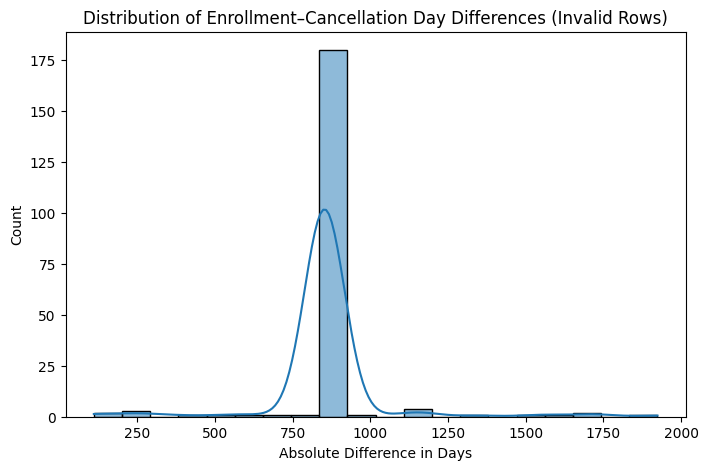

90.0% of invalid rows have ~850-day gaps (800–900 days).


In [28]:
customers['EnrollmentDateOpening'] = pd.to_datetime(customers['EnrollmentDateOpening'])
customers['CancellationDate'] = customers['CancellationDate'].replace('not canceled', pd.NaT)
customers['CancellationDate'] = pd.to_datetime(customers['CancellationDate'], errors='coerce')

invalid_cancellations = customers[(customers['CancellationDate'].notna()) &(customers['EnrollmentDateOpening'] > customers['CancellationDate'])
].copy()


if len(invalid_cancellations) > 0:
    invalid_cancellations['AbsDaysDiff'] = (invalid_cancellations['EnrollmentDateOpening'] - invalid_cancellations['CancellationDate']).dt.days.abs()

    print("Absolute day differences (Enrollment - Cancellation):\n")
    print(invalid_cancellations['AbsDaysDiff'].describe())

    std = invalid_cancellations['AbsDaysDiff'].std()
    mean = invalid_cancellations['AbsDaysDiff'].mean()
    print(f"\nMean difference: {mean:.1f} days")
    print(f"Standard deviation: {std:.1f} days")

    plt.figure(figsize=(8, 5))
    sns.histplot(invalid_cancellations['AbsDaysDiff'], bins=20, kde=True, palette='viridis')
    plt.title("Distribution of Enrollment–Cancellation Day Differences (Invalid Rows)")
    plt.xlabel("Absolute Difference in Days")
    plt.ylabel("Count")
    plt.show()

    clustered = invalid_cancellations['AbsDaysDiff'].between(800, 900).mean() * 100
    print(f"{clustered:.1f}% of invalid rows have ~850-day gaps (800–900 days).")

else:
    print("No invalid enrollment/cancellation order found.")


By analyzing these records, we found that about 75% showed a consistent gap of arround 850 days (≈2 years and 4 months) between the two dates. This consistent offset can indicate a systematic data-entry error or an accidental column swap. The remaining 25% had random gaps so we are assuming these are errors.

In order to fix these incosistencies we will swap the dates for rows that match the consistent pattern (~800–900 days apart) and drop these "outlier" rows with inconsistent gaps.

In [29]:
mask_invalid = (customers['CancellationDate'].notna()) & (customers['EnrollmentDateOpening'] > customers['CancellationDate']
)

customers['AbsDaysDiff'] = (customers['EnrollmentDateOpening'] - customers['CancellationDate']).dt.days.abs()

swap_mask = mask_invalid & customers['AbsDaysDiff'].between(800, 900)
drop_mask = mask_invalid & ~customers['AbsDaysDiff'].between(800, 900)

customers.loc[swap_mask, ['EnrollmentDateOpening', 'CancellationDate']] = (customers.loc[swap_mask, ['CancellationDate', 'EnrollmentDateOpening']].values
)

print(f"Swapped {swap_mask.sum()} rows where date reversal pattern was systematic (~850 days apart).")

customers = customers.drop(customers[drop_mask].index)
print(f"Dropped {drop_mask.sum()} inconsistent rows with irregular date differences.")

customers.drop(columns=['AbsDaysDiff'], inplace=True)

customers['CancellationDate'] = customers['CancellationDate'].fillna('not canceled')


Swapped 181 rows where date reversal pattern was systematic (~850 days apart).
Dropped 20 inconsistent rows with irregular date differences.


In [30]:
customers['EnrollmentDateOpening'] = pd.to_datetime(customers['EnrollmentDateOpening'])
customers['CancellationDate'] = pd.to_datetime(customers['CancellationDate'], errors='coerce')

last_day = pd.Timestamp('2023-01-01')

customers['EffectiveEndDate'] = np.where(customers['IsCanceled'] == 1,customers['CancellationDate'], last_day)

customers['EffectiveEndDate'] = pd.to_datetime(customers['EffectiveEndDate'])

customers['ProgramDaysDuration'] = (customers['EffectiveEndDate'] - customers['EnrollmentDateOpening']).dt.days

customers.drop(columns=['EffectiveEndDate'], inplace=True)


/var/folders/hw/9xdxx_2x1yngcbg5k1r1r3yw0000gn/T/ipykernel_91296/1819029979.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customers['CancellationDate'] = pd.to_datetime(customers['CancellationDate'], errors='coerce')


We also found it helpful to created the numerical feature `ProgramDaysDuration` that gives us the number of days that the customers has joined the loyalty program, due to the categorical nature od `EnrollmentDateOpening` and `CancelationDate`, so we decided to drop this ones.

In [31]:
customers.drop(columns=["EnrollmentDateOpening", "CancellationDate"],inplace=True)

#### 2.3.3 Descriptive Statistics

In [32]:
customers.describe(include='all')

,Loyalty#,Province or State,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,IsCanceled,ProgramDaysDuration
count,16717.000000,16717,16717,16717,16717,16717.000000,16717,16717,16717.000000,16717,16717.000000,16715.000000
unique,NaN,11,2,5,3,NaN,3,3,NaN,2,NaN,NaN
top,NaN,Ontario,female,Bachelor,Suburban,NaN,Married,Star,NaN,Standard,NaN,NaN
freq,NaN,5399,8397,10465,5647,NaN,9725,7630,NaN,15592,NaN,NaN
mean,549778.550278,NaN,NaN,NaN,NaN,37756.760065,NaN,NaN,7989.806309,NaN,0.134474,1418.206461
std,258863.149331,NaN,NaN,NaN,NaN,30364.316137,NaN,NaN,6862.880199,NaN,0.341171,785.994630
min,100018.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1898.010000,NaN,0.000000,0.000000
25%,326724.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,3981.780000,NaN,0.000000,715.000000
50%,550539.000000,NaN,NaN,NaN,NaN,34161.000000,NaN,NaN,5780.180000,NaN,0.000000,1360.000000
75%,771960.000000,NaN,NaN,NaN,NaN,62396.000000,NaN,NaN,8940.580000,NaN,0.000000,2106.000000


After cleaning this part of the dataset, with the method `.describe()` we can take out some small analysis:
- `Loyalty#` - No statistics analysis important cause it's just a unique identifier of the customer.
- `Customer name`, `Province or State`, `Gender`, `Education`, `Location code`, `Marital Status`, `LoyaltyStatus`, `EnrollmentType` and `IsCanceled` - Nominal categoric features with no important statistics to mention besides the mode.
- `Income` - The mean being 37756.76 comparing to the median of 34161.0	shows a slightly right asymmetry. 25% of the data has 0 income as we had saw before the college students.
- `Customer Lifetime Value` - There is also a a slightly right asymmetry since the mean is higher the the median. The values range between 1898.01 and 83325.38.
- `ProgramDaysDuration` - The mean and the median has a really small difference, witch show us that the distribution of this feature is almost symmetric.


### 2.4 Visualization

#### 2.4.1 Histograms

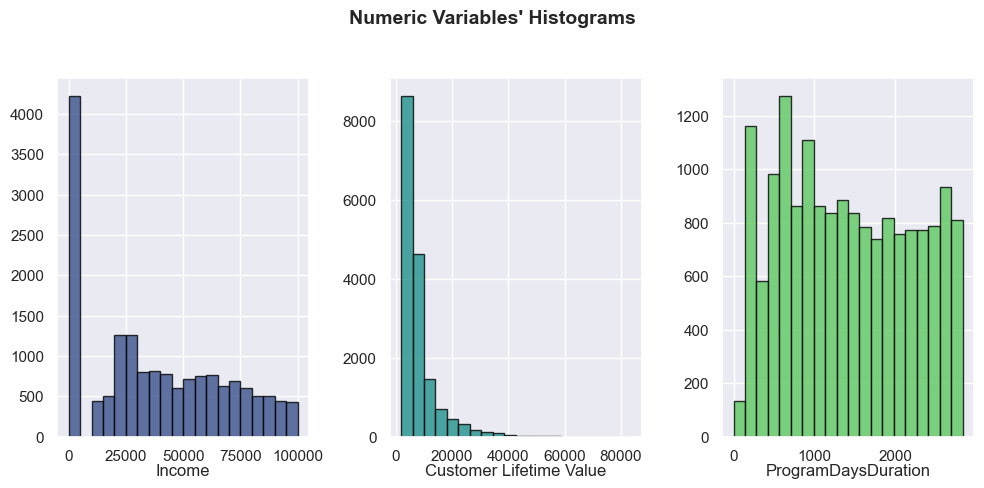

In [33]:

metric_features = ['Income', 'Customer Lifetime Value', 'ProgramDaysDuration']
sns.set(style="darkgrid") 

# Get 3 colors from the 'viridis' palette
colors = sns.color_palette('viridis', n_colors=len(metric_features))

sp_rows = 1
sp_cols = 3

# Prepare figure
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(10, 5))

# Plot data with colors
for ax, feat, color in zip(axes.flatten(), metric_features, colors):
    ax.hist(customers[feat], bins=20, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(feat, y=-0.13)

# Layout
plt.suptitle("Numeric Variables' Histograms", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


These histograms show the distribution of three numerical values: `Income`, `Customer Lifetime Value` and `Program Days Duration`:

- The distribution of the `Income` variable is right-skewed, meaning that most customers have a lower income (bellow 25.000), with only a few earning substantially more. Most of AIAI's customers are low-income individuals, while high-income customers exist but in a small fraction. The company might want to focus on affordable, value-driven products or services to cater to the majority, consider segmenting the high-income minority for premium plans or exclusive loyalty programs or use income-based segmentation for targeted marketing campaigns.

- `CLV` also appears heavely right-skewed, with most customers having a relatively low value, while a very small number generate a higher CLV. This suggests that a small portion of customers drive a large portion of revenue.

- As for the final feature `ProgramDaysDuration` the distribution appears relatively uniform with customers participating across a wide range of durations, showing a consistent engagement and no specific cancelation point. 
 



#### 2.4.2 Boxplots

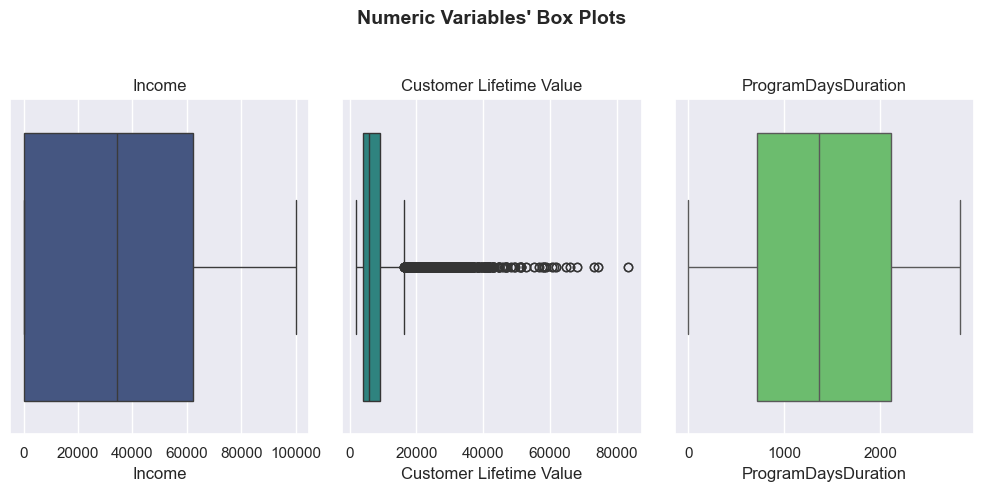

In [34]:
sns.set(style="darkgrid")
sp_rows = 1
sp_cols = 3

fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(10, 5), tight_layout=True)

colors = sns.color_palette('viridis', n_colors=len(metric_features))

for ax, feat, color in zip(axes.flatten(), metric_features, colors):
    sns.boxplot(x=customers[feat], ax=ax, color=color)
    ax.set_title(feat)

plt.suptitle("Numeric Variables' Box Plots", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


- The `Income` distribution has a median close to the center of the box, suggesting a somewhat balanced distribution, though the histogram earlier showed slight right skewness. There are no major outliers, but variation is considerable — indicating customers come from diverse income levels.

- The `Customer Lifetime Value`boxplot has a inter-quartile range (IQR) with a small relative scale, meaning most customers cluster within a low CLV range. There are many high-value outliers, representing a small group of customers with disproportionately high lifetime value. 

- As we had seen before the feature `ProgramDaysDuration` has an uniform distribution.

#### 2.4.3 Visualization of categorical variables

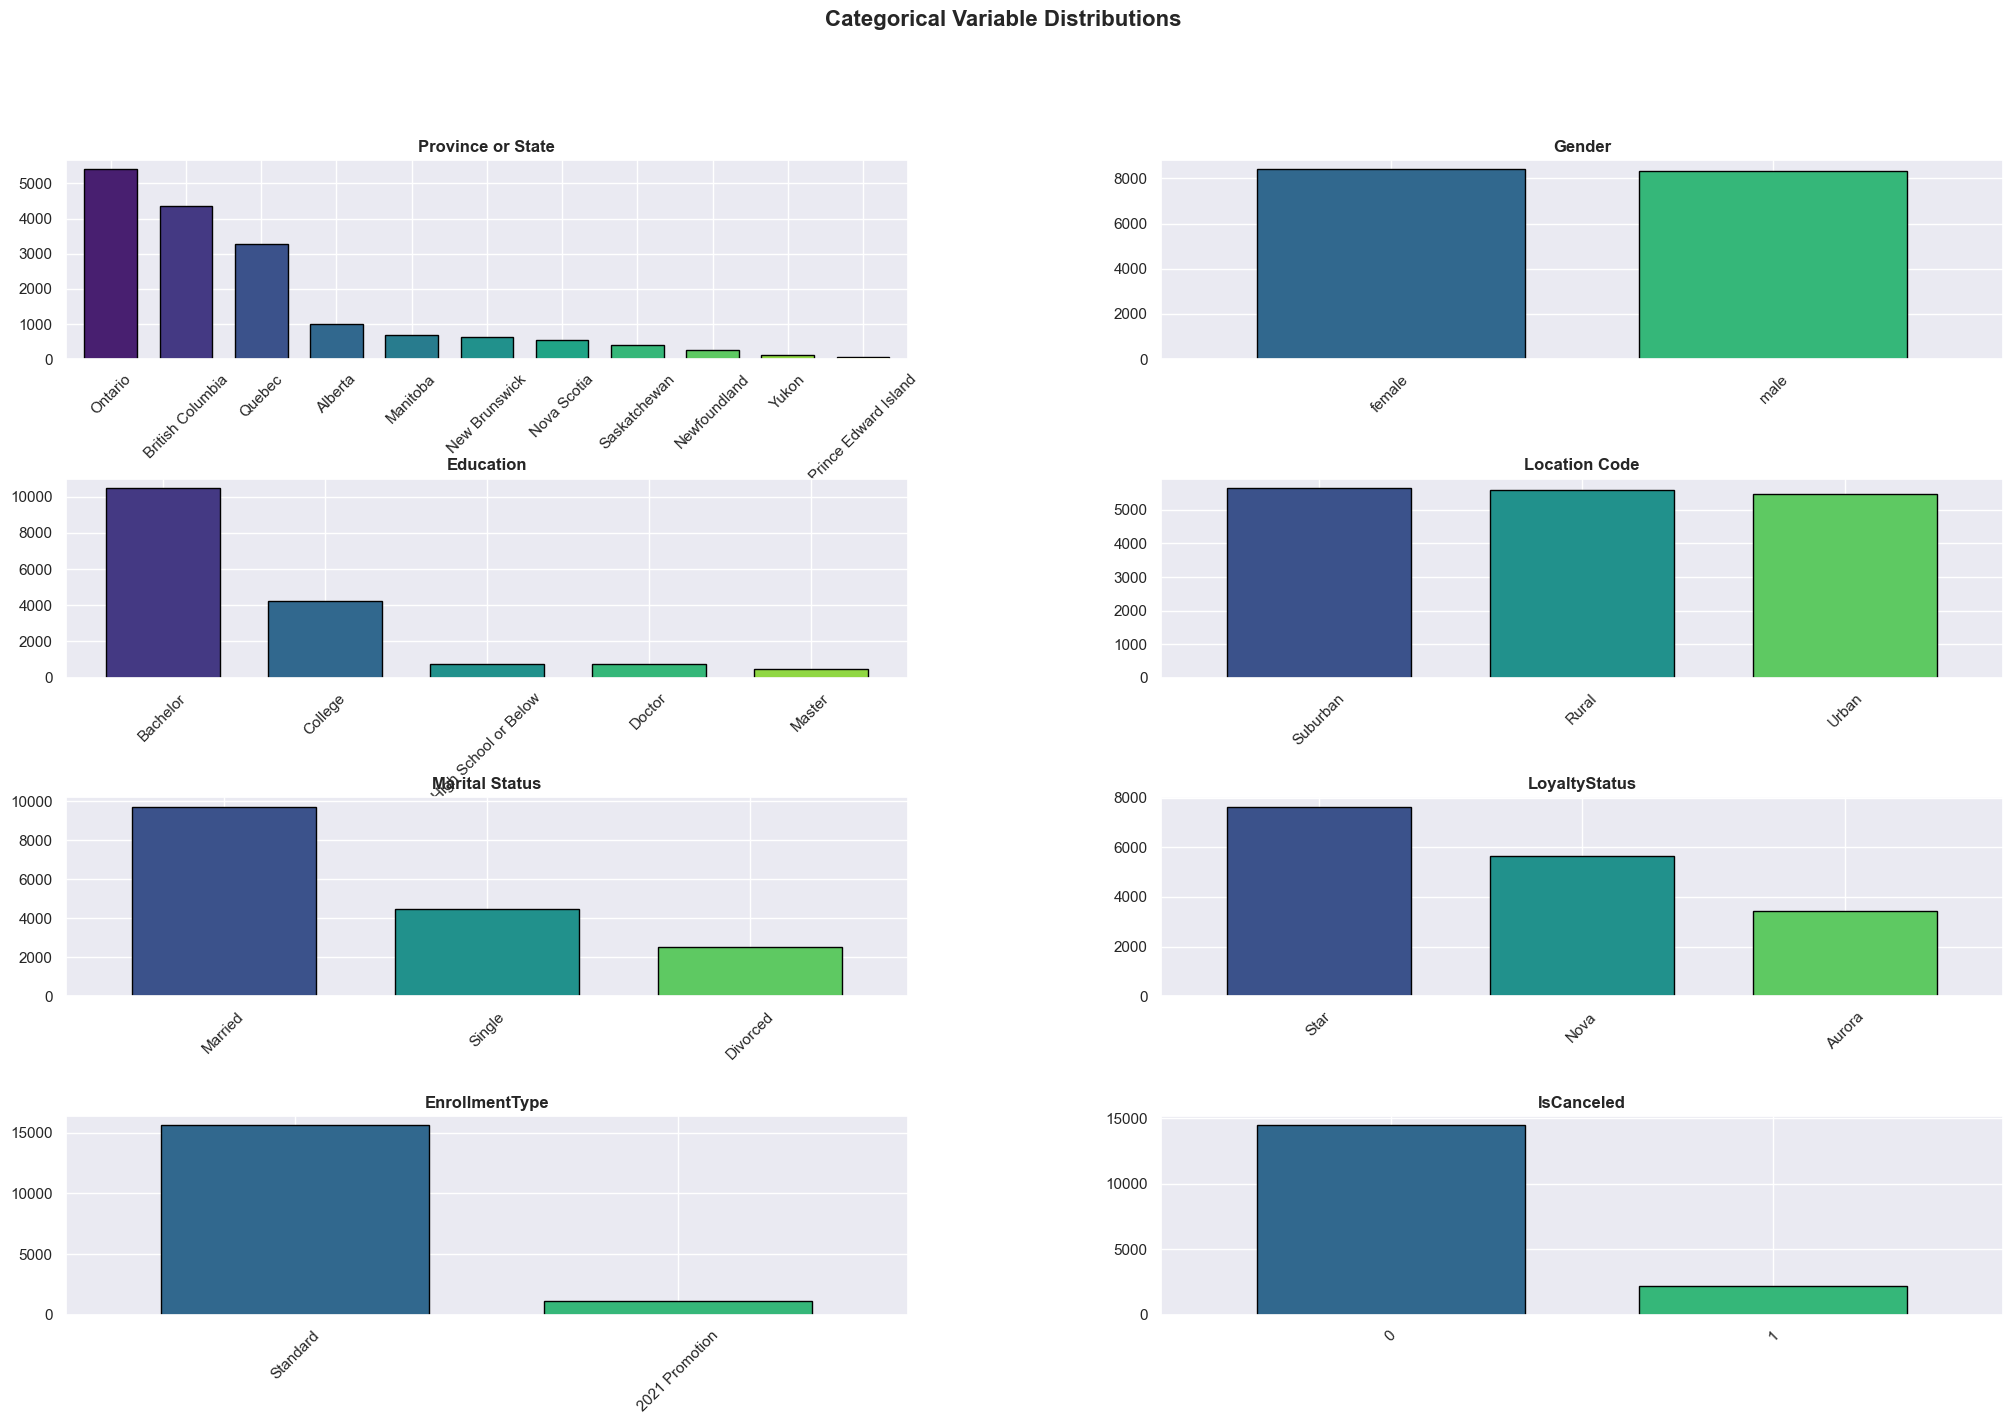

In [35]:
cat_vars = ['Province or State', 'Gender', 'Education', 'Location Code',
            'Marital Status', 'LoyaltyStatus', 'EnrollmentType', 'IsCanceled']

sns.set(style="darkgrid")
fig, axes = plt.subplots(4, 2, figsize=(25, 15))

for ax, feat in zip(axes.flatten(), cat_vars):
    colors = sns.color_palette('viridis', n_colors=customers[feat].nunique())
    customers[feat].value_counts().plot.bar(
        ax=ax, 
        width=0.7, 
        color=colors, 
        edgecolor='black'
    )
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(hspace=0.6, wspace=0.3)
plt.suptitle("Categorical Variable Distributions", fontsize=16, fontweight='bold')
plt.show()


From this graphs we get a good overview of the customers' demographic characteristics and can take some helpfull insights:

- As for `Province or State`, a big part of the customer base is concentrated in Ontario, followed by British Columbia and Quebec, with the remaining provinces contributing with a significantly smaller amount of customers.

- In the `Gender`bar plot, we get a well balanced distribution between male and female, segmentating by gender probably wont provide any usefull insights.

- A very large share of customers have a Bachelor’s degree, followed by College. Very few have high school or advanced degrees (Master’s/Doctorate). The customer base is relatively well-educated.

- With the `Marital Status`distribution, we found that most of customers are married, followed by single and divorced individuals. 

- Most customers have “Star” `Loyalty Status`, followed by “Nova” and “Aurora”.

- A very significant part of the data is composed by "Standard" `Enrollment Type`, with very few individuals signing up from the "2021 Promotion".

- Finally, for the `isCanceled`feature, most customers have *not* cancelled(0), with a very small group canceling their subscription.



#### 2.4.4 Comparing a categorical variable `Education` vs numeric variables

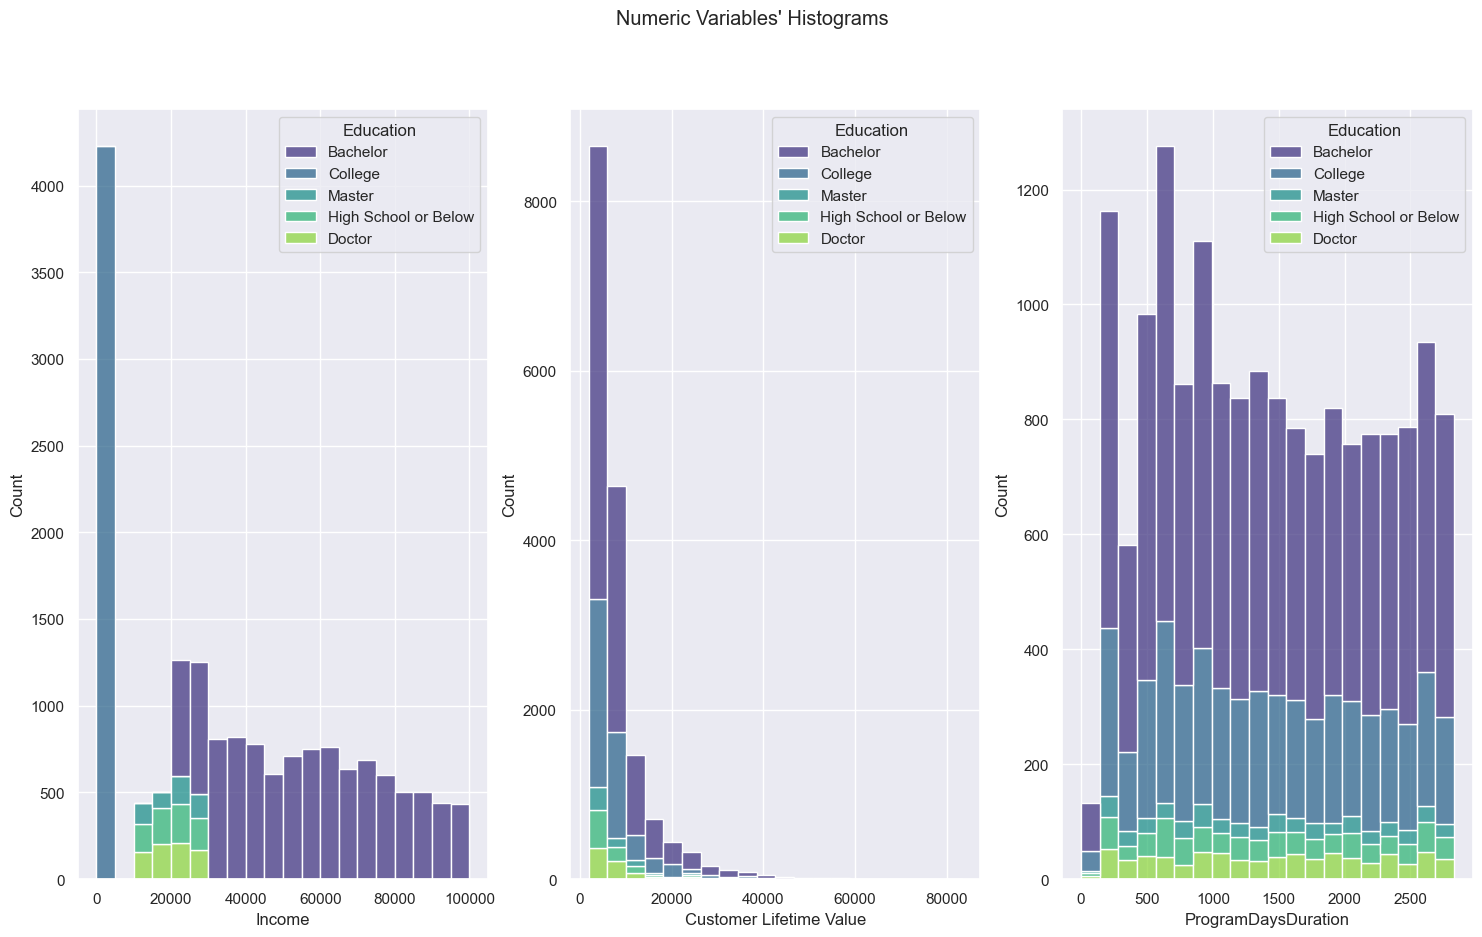

In [36]:
sp_rows = 1
sp_cols = 3
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(18, 10))
for ax, feat in zip(axes.flatten(), metric_features): 
        sns.histplot(
        data=customers,
        x=feat,
        hue='Education',
        bins=20,
        multiple='stack',
        palette='viridis',
        ax=ax
    )

# Layout
title = "Numeric Variables' Histograms"

plt.suptitle(title)

plt.show()

With this graphs we can come out with a few insights:
- The College group shows an extremely high spike at 0, witch confirms what we concluded earlier since many college-level customers have no recorded `income`.
- For other education levels, `income` doesn't appear to rise with education:
    - Bachelor’s show a broader and higher income distributions.
    - High School or below, Masters and Doctorates seem to cluster at lower income ranges.
- For the `Customers Life Value` and `ProgramDaysDuration` there is a uniform distribution per the education levels, with the bachelor's representing more lower values of the `Customer Life Value`.



#### 2.4.5 Comparing a categorical variable `Marital Status` vs numeric variables

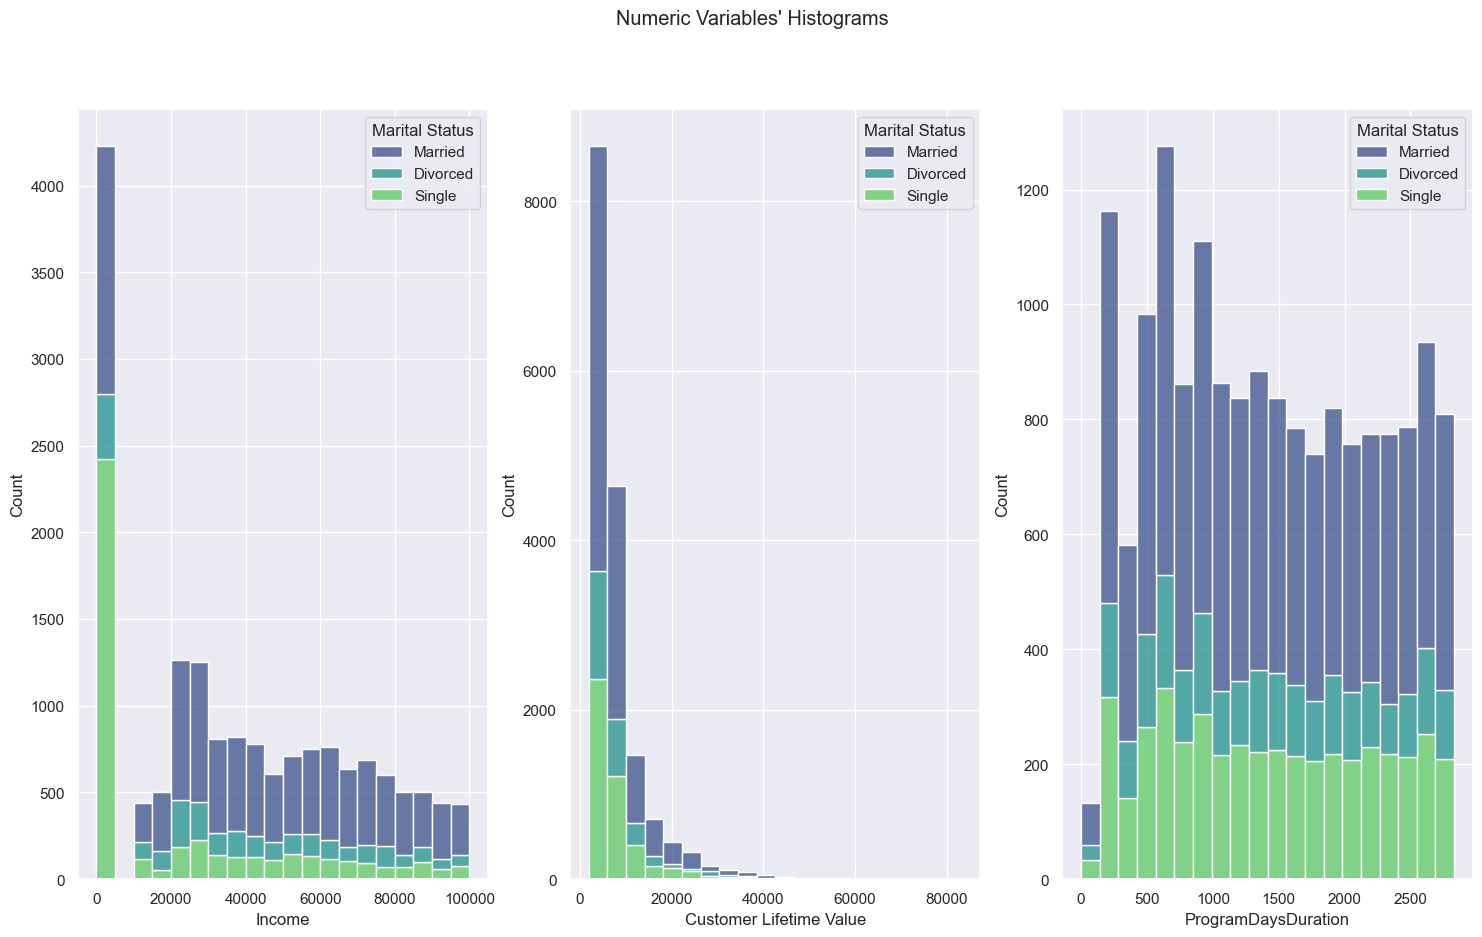

In [37]:
sp_rows = 1
sp_cols = 3
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), metric_features): 
    sns.histplot(customers, x=feat, palette='viridis',ax=ax, bins=20, hue= 'Marital Status', multiple='stack')

title = "Numeric Variables' Histograms"

plt.suptitle(title)

plt.show()

In this `Marital status` graphs there is some interesting things:
- The `Income` distribution shows that married individuals generally have higher and more widely distributed incomes compared to single or divorced individuals. Single individuals mostly fall within the lowest income range, indicating limited earning capacity for this group.
- Divorced individuals appear less represented overall, with income levels spread across mid-to-lower ranges.
- For `Customer Lifetime Value`, married customers dominate the distribution, particularly in the lower range, but also extend into higher values.
- Overall, marital status seems to influence both `Income` and `Customer Lifetime Value`, with married individuals showing higher economic activity and value compared to singles or divorced customers.
- The histogram for `ProgramDaysDuration` shows that married individuals make up the largest portion across all duration ranges, followed by single and then divorced participants.

#### 2.4.6 Comparing a categorical variable `LoyaltyStatus` vs numeric variables

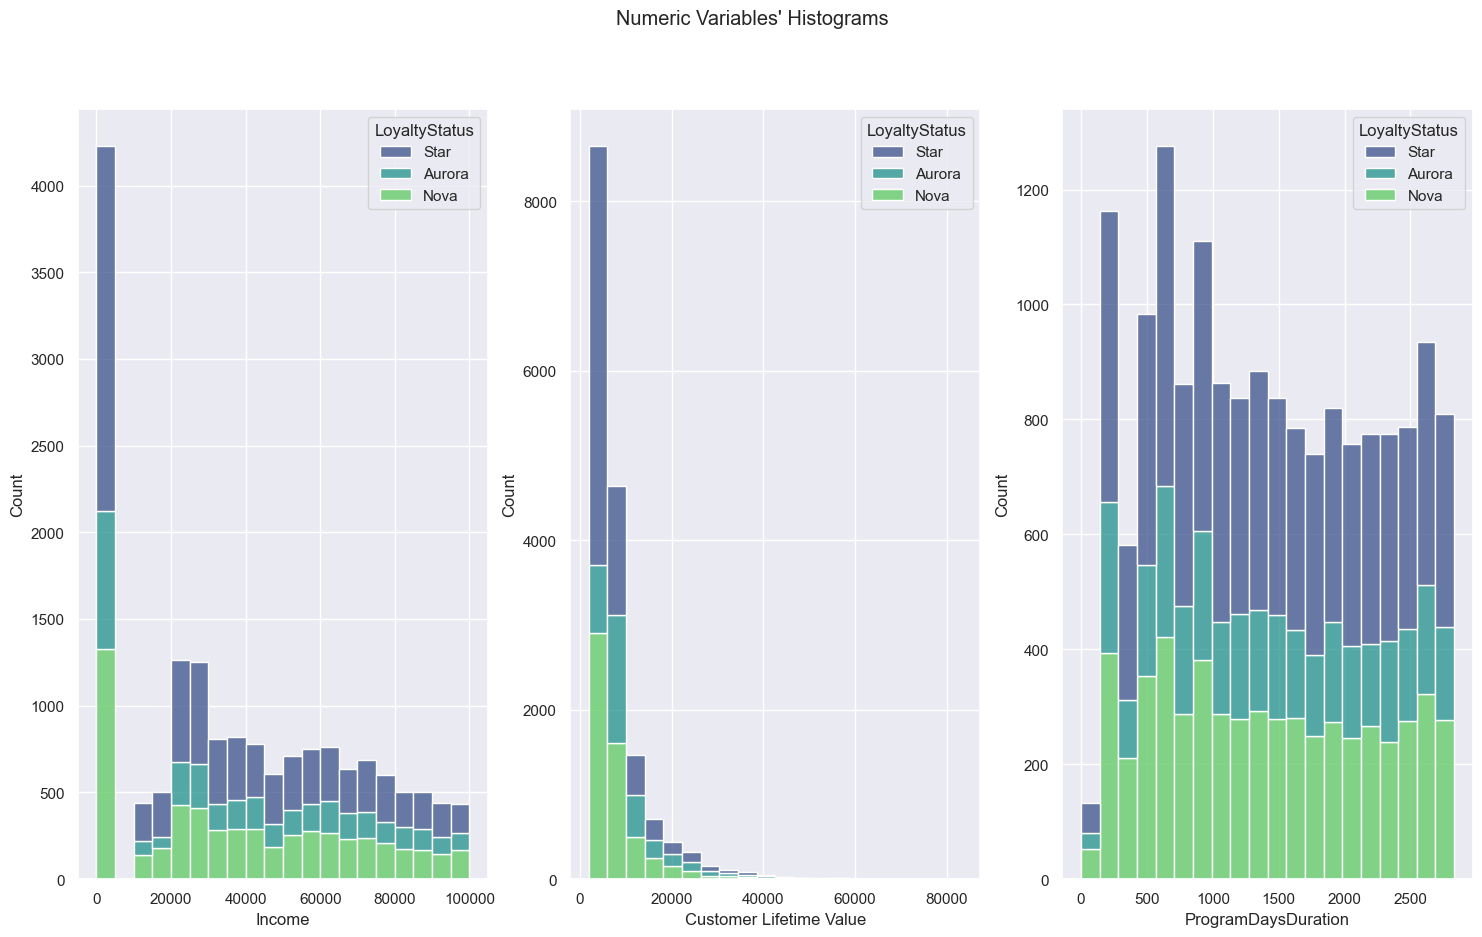

In [38]:
sp_rows = 1
sp_cols = 3
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), metric_features): 
    sns.histplot(customers, x=feat, palette='viridis', ax=ax, bins=20, hue= 'LoyaltyStatus', multiple = 'stack')

title = "Numeric Variables' Histograms"

plt.suptitle(title)

plt.show()

After analyzing the graph above we conclude that:
- The `Income` distribution shows that customers with Star loyalty status are the most frequent across all income levels, particularly at the lower end. Aurora members are also well represented but show a slightly wider spread in income while, Nova members appear in smaller numbers overall, with some concentration in the mid-income ranges.
- In the `Customer Lifetime Value` distribution, Star members again dominate, with most values clustered in the lower range. 
- Overall, higher loyalty status seems correlated with both higher income and Customer Lifetime Value, suggesting that more loyal customers may contribute more value to the company over time.
- The distribution of the categorical feature `LoyaltyStatus` appears relatively consistent across `ProgramDaysDuration`, with no major differences in participation time. This can suggest that program stay isn't necessarly related to loyalty status since all three groups show a steady program stay over time.


/var/folders/hw/9xdxx_2x1yngcbg5k1r1r3yw0000gn/T/ipykernel_91296/1947011749.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


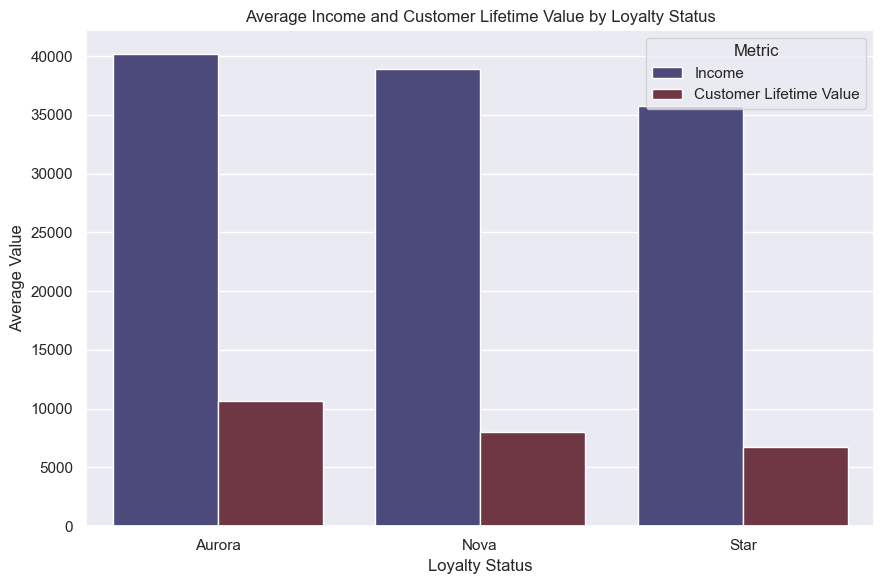

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

avg_stats = (
    customers.groupby('LoyaltyStatus')[['Income', 'Customer Lifetime Value']]
    .mean()
    .reset_index()
)

avg_stats_long = avg_stats.melt(
    id_vars='LoyaltyStatus',
    value_vars=['Income', 'Customer Lifetime Value'],
    var_name='Metric',
    value_name='AverageValue'
)

fig, ax = plt.subplots(figsize=(9,6))  

sns.barplot(
    data=avg_stats_long,
    x='LoyaltyStatus',
    y='AverageValue',
    hue='Metric',
    palette='icefire',
    ci=None
)

plt.title('Average Income and Customer Lifetime Value by Loyalty Status')
plt.ylabel('Average Value')
plt.xlabel('Loyalty Status')
plt.legend(title="Metric")
plt.tight_layout()
sns.set_style("whitegrid")
plt.show()


These bar plots summarize the prior conclusions in a more intuitive ways, showing how the average `Income`and `Customer Lifetime Value`vary across loyalty status'. Both metrics show a consistent increase with increasing loyalty status. Aurora members have the highest average income (~$40,000) and highest average CLV (~$10,500), followed by Nova, while Star members record the lowest averages in both categories.

#### 2.4.6 Comparing a categorical variable `IsCancelled` vs numeric variables

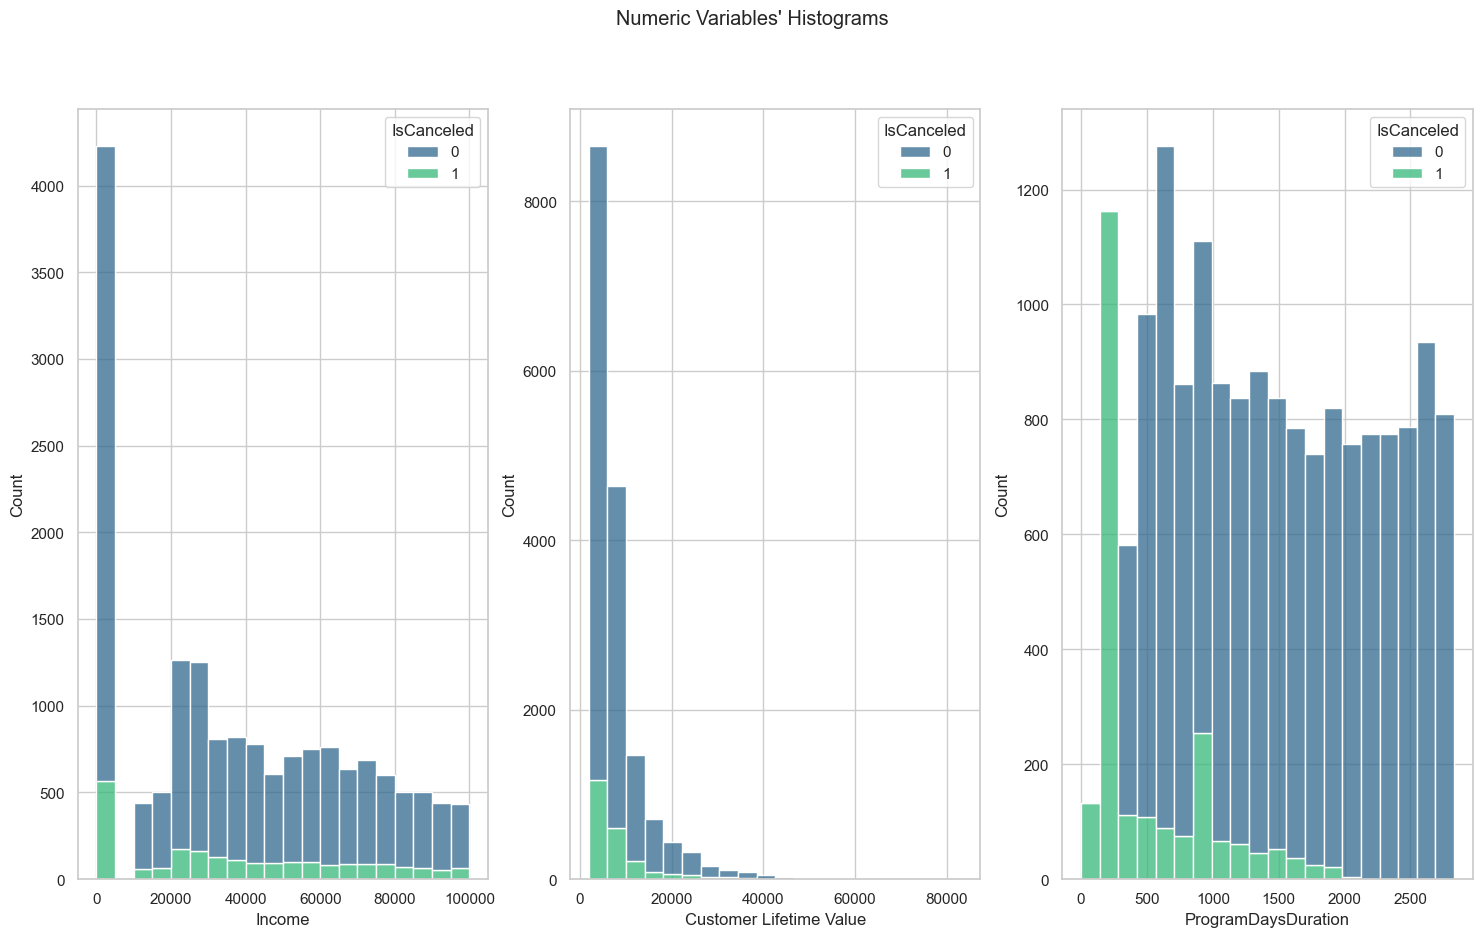

In [40]:
sp_rows = 1
sp_cols = 3
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), metric_features): 
    sns.histplot(customers, x=feat, ax=ax, bins=20,palette='viridis', hue= 'IsCanceled', multiple='stack')

title = "Numeric Variables' Histograms"

plt.suptitle(title)

plt.show()

With this two graphs we can take out some information:
- The `Income` distribution for both canceled (1) and non-canceled (0) customers is heavily skewed towards the lower end, with the highest counts occurring below 10000.
- The `Customer Lifetime Value` for both groups is also right-skewed, but the vast majority of cancellations (1) occur among customers with a lower `Customer Lifetime Value`, primarily below 10000.
- Non-canceled (0) customers have a higher count across all `Customer Lifetime Value` bins, but the largest absolute difference between the two groups is concentrated at values under 5000.
- The distribution of the feature `ProgramDaysDuration` shows a high and relatively stable volume of non-canceled(0) customers across the entire program duration, with a small, consistent absolute number of canceled(1) customers that spikes notably in the final duration bin.

#### 2.4.7 Scatterplots

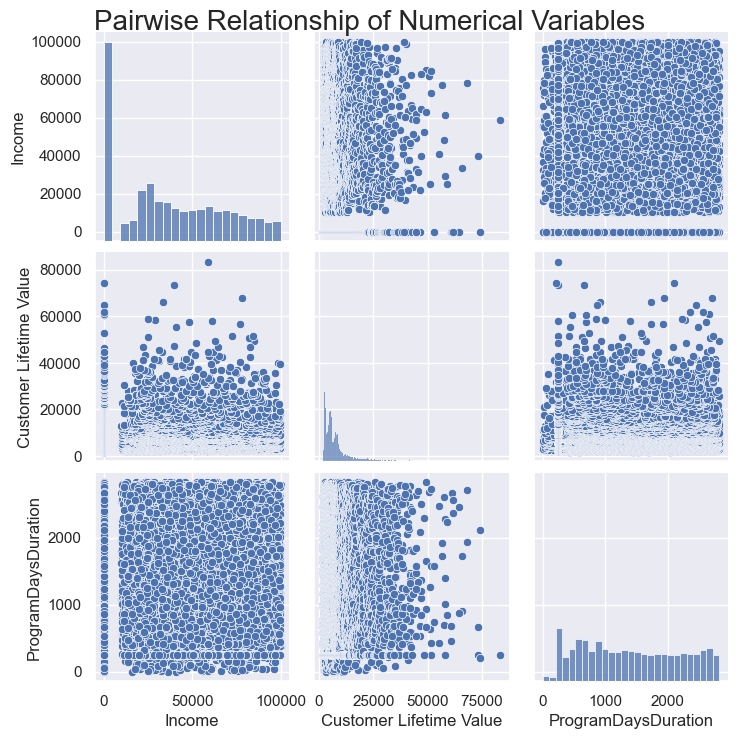

In [41]:
sns.set()

sns.pairplot(customers[metric_features], diag_kind="hist")

plt.subplots_adjust(top=0.95)
plt.suptitle("Pairwise Relationship of Numerical Variables", fontsize=20)
plt.show()

These plots show that none of the numeric variables are strongly correlated with one another, with each one capturing different aspects of the customers behavior. This way we don't get any new insights beyond what was discovered previously but confirms that these variables are mostly independent, with only a slight relationship between CLV and engagement duration.

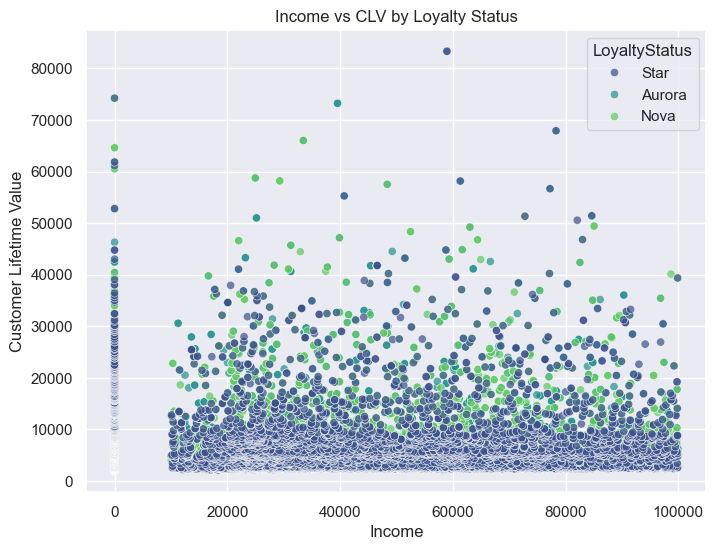

In [42]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=customers, 
                x='Income', 
                y='Customer Lifetime Value', 
                hue='LoyaltyStatus', 
                alpha=0.7,
                palette='viridis')
plt.title('Income vs CLV by Loyalty Status')
plt.show()


Based on this scatterplot, we can acess that there is no strong linear correlation between `Income`and `CLV`, as customers with different income backgrounds show different lifetime values. However, we can clearly distinguish some insights:

- Aurora members (to-tier loyalty status) tend to cluster at higher CLV values, often across a broad range of incomes, which idicates that loyalty level has a bigger part in a customer's clv than income.
- Nova members ocuppy mid and high CLV ranges. However, these are fewer in number especially in comparisson with Star members, who strongly occupy the lower CLV region. 

This reinforces that while income alone does not predict CLV, loyalty level is a key differentiator since higher loyalty tiers consistently align with greater clv , regardless of income.

#### 2.4.8 KDE of the numeric features

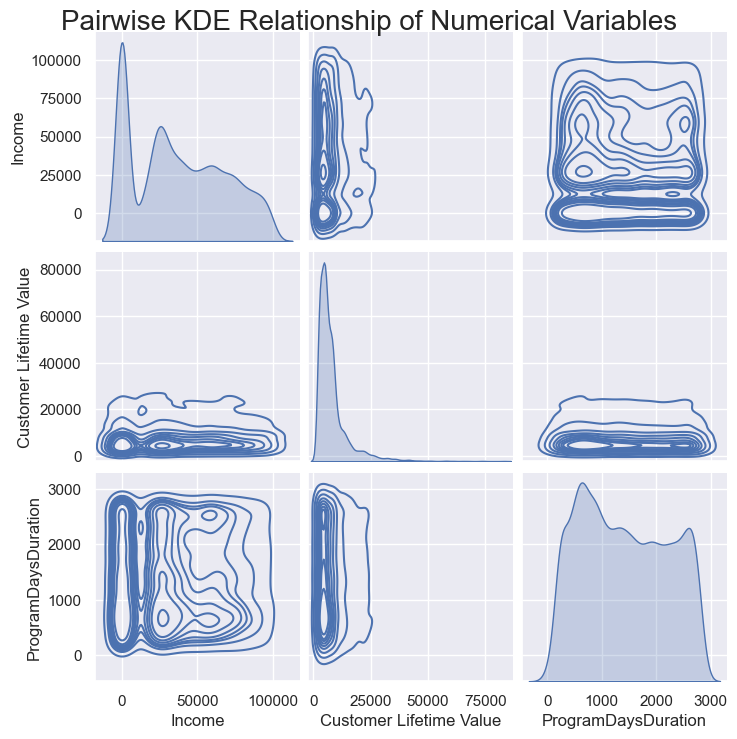

In [43]:
sns.pairplot(
    customers[metric_features],
    diag_kind="kde",   
    kind="kde"         
)

plt.subplots_adjust(top=0.95)
plt.suptitle("Pairwise KDE Relationship of Numerical Variables", fontsize=20)
plt.show()

Based on the KDE plots:
- `Income` vs `Customer Lifetime Value`: Strong density mass confirming that the high concentration of low lifetime value customers is present across all income levels.
- `Income` vs `ProgramDaysDuration`: Rectangular density contours show that all program durations are equally common within the two main income density clusters.
- `Customer Lifetime Value` vs `ProgramDaysDuration`: Strong, vertical density mass confirming that the high concentration of low lifetime value customers is present across all program durations.

This KDE plot reinforces earlier findings, with the key insight being that the dataset has right-skewed `Income`and `CLV`distributions.

#### 2.4.9 Correlation matrix

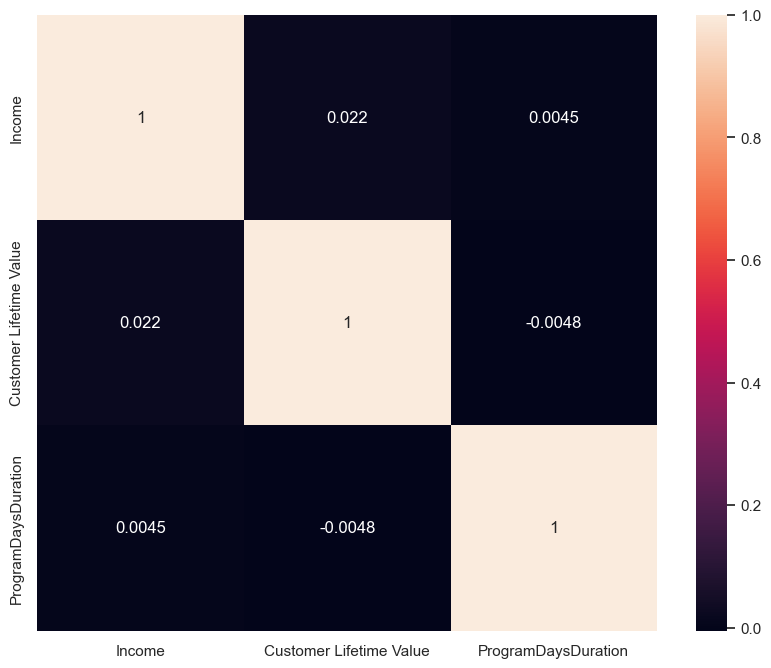

In [44]:
corr = customers[metric_features].corr(method="pearson")

fig = plt.figure(figsize=(10, 8))

sns.heatmap(data=corr, annot=True, )

plt.show()


There is no string correlations between the metric features of the `customers` data set, confirming what we expected, to take better analysis of this airlines we have to merge them with the other data set.

### 2.5 Checking outliers

We noticed that the outliers are a big part of our that set, so it's necessary to check if there is a significant presence of them, to avoid their potential negative impact on our analysis.

In [45]:
numeric_only = customers.select_dtypes(include=[np.number])
q1 = numeric_only.quantile(0.25)
q3 = numeric_only.quantile(0.75)
iqr = q3 - q1
outliers = ((numeric_only < (q1 - 1.5 * iqr)) | (numeric_only > (q3 + 1.5 * iqr))).sum()
outliers

Loyalty#                      0
Income                        0
Customer Lifetime Value    1483
IsCanceled                 2248
ProgramDaysDuration           0
dtype: int64

Checking if they have a high impact in our data set.

In [46]:
outlier_mask = ((numeric_only < (q1 - 1.5 * iqr)) | (numeric_only > (q3 + 1.5 * iqr)))
outlier_rows = outlier_mask.any(axis=1)
num_outlier_rows = outlier_rows.sum()

print(f"The presence of outliers is {(num_outlier_rows/len(customers))*100:.2f}% of the dataset.")

The presence of outliers is 21.02% of the dataset.


Since the percentage of that set that has outliers is really big, we will have to take care of them on the pre-process data in the next step of this project.

## 3. Flights data analysis

### 3.1 Importing the data

In [47]:
flights = pd.read_csv('https://raw.githubusercontent.com/catamina07/datamining-group/64d5edb1e1a39716e570308abb8b803f43144806/data/DM_AIAI_FlightsDB.csv')
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


### 3.2 Metadata
- *id* - The unique identifier of the customer
- *Loyalty#* - Unique customer identifier linking to CustomerDB
- *Year* - Year of flight activity record
- *Month* -	Month of flight activity record (1-12)
- *YearMonthDate* -	First day of the month for the activity period
- *NumFlights* -	Total number of flights taken by customer in the month
- *NumFlightsWithCompanions* -	Number of flights where customer traveled with companions
- *DistanceKM* -	Total distance traveled in kilometers for the month
- *PointsAccumulated* -	Loyalty points earned by customer during the month
- *PointsRedeemed* -	Loyalty points spent/redeemed by customer during the month
- *DollarCostPointsRedeemed* -	Dollar value of points redeemed during the month

### 3.3 Initial Analysis

Using the `.shape()` method, we can visualize how many rows and columns has our datasets.<br>

In [48]:
flights.shape

(608436, 10)

In this initial dataset there is 608436 rows e 10 columns.

Using the `.columns` method, we can visualize the names of the columns of our datasets.<br>

In [49]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed'],
      dtype='object')

The method `.head()` is used to take a first look at the data, displaying the first five rows of every feature in the train dataset.

In [50]:
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


The method `.tail()` is used to take a first look at the data, displaying the last five rows of every feature in the  train dataset.

In [51]:
flights.tail()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
608431,999902,2019,12,12/1/2019,7.2,0.0,30766.5,3076.65,0.0,0.0
608432,999911,2019,12,12/1/2019,0.0,0.0,0.0,0.00,0.0,0.0
608433,999940,2019,12,12/1/2019,14.4,0.9,18261.0,1826.10,0.0,0.0
608434,999982,2019,12,12/1/2019,0.0,0.0,0.0,0.00,0.0,0.0
608435,999986,2019,12,12/1/2019,0.0,0.0,0.0,0.00,0.0,0.0


Using these two methods made it possible to view the first and last five rows, respectively. This information can be used to draw important conclusions about the data, such as:

* The variable `Loyalty#` can be set as an index, using the method `set_index()` from pandas;

* There are different types of data, such as:

    * `Categorical` -> Ordinal;<br>
    * `Numerical` -> Discrete and Continuous

In [52]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [53]:
flights.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
YearMonthDate                object
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

Using the `.info()` and `.dtypes` methods, we can take out some information of this data set:
- Non-null Count
- Dtype
    - int64
    - object
    - float64


#### 3.3.1 Checking missing values

In [54]:
flights.replace("", np.nan, inplace=True)
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

There is no missing values in any variable in this dataset.

#### 3.3.2 Checking duplicates

In [55]:
flights.duplicated().sum()

2903

With the combined functions `.duplicated().sum()`we checked the duplicates on the data set, witch was 2903, so we have to take care of them.

In [56]:
total_rows = len(flights)
rows_after_dropping_duplicates = len(flights.drop_duplicates())
rows_removed = total_rows - rows_after_dropping_duplicates
percent_removed = (rows_removed / total_rows) * 100
percent_removed

0.4771249564457067

Since the percentage of deleted rows is only 0.48% of the total rows. we decided to delete them to prevent from corrupting the data.

In [57]:
flights = flights.drop_duplicates()

In [58]:
flights.duplicated(subset=['Loyalty#']).sum()

588796

In [59]:
flights[flights['Loyalty#'] == 999902].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loyalty#,36.0,NaN,NaN,NaN,999902.0,0.0,999902.0,999902.0,999902.0,999902.0,999902.0
Year,36.0,NaN,NaN,NaN,2020.0,0.828079,2019.0,2019.0,2020.0,2021.0,2021.0
Month,36.0,NaN,NaN,NaN,6.5,3.50102,1.0,3.75,6.5,9.25,12.0
YearMonthDate,36,36,5/1/2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumFlights,36.0,NaN,NaN,NaN,7.419444,4.875233,0.0,2.925,7.6,11.0,17.0
NumFlightsWithCompanions,36.0,NaN,NaN,NaN,2.105556,2.476858,0.0,0.0,1.0,4.125,8.0
DistanceKM,36.0,NaN,NaN,NaN,16948.875,10399.144349,0.0,8684.3,18099.85,23247.0,34185.0
PointsAccumulated,36.0,NaN,NaN,NaN,1694.626389,1039.877566,0.0,868.28,1809.585,2324.25,3418.0
PointsRedeemed,36.0,NaN,NaN,NaN,291.716667,988.411417,0.0,0.0,0.0,0.0,3962.0
DollarCostPointsRedeemed,36.0,NaN,NaN,NaN,2.863889,9.708234,0.0,0.0,0.0,0.0,39.0


We used the same function as before to check it the feature `Loyalty#` was unique, witch wasn't, so that means that different people share the same loyalty number or the same person is in multiple rows, so we have to take care of them. Before doing that we will make a small analysis of the flights per month since we will lose that data.

Since there are multiple entries for the same customer's flights each month, we decided to modify the flights dataset to provide more comprehensive information on each customer and to facilitate a future merge in mind with `CustomersDB`. However, we will keep a copy of the current dataset in order to track seasonality over time.

New features
- `TotalFlights`: the total number of flights the customer took over the observed period.
- `TotalFlightsWithCompanions`: the total number of flights taken with companions.
- `TotalDistanceKM`: total distance traveled in kilometers.
- `TotalPointsAccumulated`: total loyalty points earned.
- `TotalPointsRedeemed`: total loyalty points spent.
- `TotalDollarCostPointsRedeemed`: total dollar value of points redeemed.
- `AvgFlightsPerMonth`: average number of flights per month.
- `AvgPointsPerMonth`: average points earned per month.
- `MaxFlightsInMonth` / `MaxPointsInMonth `: peak activity in a single month, identifying high-intensity periods.
- `CompanionFlightRatio`: proportion of flights taken with companions relative to total flights.
- `SoloflightRatio`: proportion of flights taken solo relative to total flights.
- `AvgCompanionsPerFlight`: average number of flights with companions per flight.
- `PointsRedeemedPerFlight`: average points redeemed per flight, reflecting loyalty program usage patterns.

In [60]:
flights_original = flights.copy()
MonthsTotal = flights['YearMonthDate'].nunique()

flights = flights.groupby('Loyalty#').agg(
    TotalFlights=('NumFlights', 'sum'),
    TotalFlightsWithCompanions=('NumFlightsWithCompanions', 'sum'),
    TotalDistanceKM=('DistanceKM', 'sum'),
    TotalPointsAccumulated=('PointsAccumulated', 'sum'),
    TotalPointsRedeemed=('PointsRedeemed', 'sum'),
    TotalDollarCostPointsRedeemed=('DollarCostPointsRedeemed', 'sum'),
    AvgFlightsPerMonth=('NumFlights', 'mean'),
    AvgPointsPerMonth=('PointsAccumulated', 'mean'),
    MaxFlightsInMonth=('NumFlights', 'max'),
    MaxPointsInMonth=('PointsAccumulated', 'max'),
    CompanionFlightRatio=('NumFlightsWithCompanions',
        lambda x: x.sum() / flights.loc[x.index, 'NumFlights'].sum()
        if flights.loc[x.index, 'NumFlights'].sum() != 0 else 0),
    SoloFlightRatio=('NumFlightsWithCompanions',
        lambda x: 1 - (
            x.sum() / flights.loc[x.index, 'NumFlights'].sum()
            if flights.loc[x.index, 'NumFlights'].sum() != 0 else 0
        )
    ),
    PointsRatio=('PointsRedeemed',
        lambda x: x.sum() / flights.loc[x.index, 'PointsAccumulated'].sum()
        if flights.loc[x.index, 'PointsAccumulated'].sum() != 0 else 0),
    PointsPerKM=('PointsAccumulated',
        lambda x: x.sum() / flights.loc[x.index, 'DistanceKM'].sum()
        if flights.loc[x.index, 'DistanceKM'].sum() != 0 else 0),
    PointsRedeemedPerFlight=('PointsRedeemed',
        lambda x: x.sum() / flights.loc[x.index, 'NumFlights'].sum()
        if flights.loc[x.index, 'NumFlights'].sum() != 0 else 0),
    AvgCompanionsPerFlight=('NumFlightsWithCompanions',
        lambda x: x.sum() / flights.loc[x.index, 'NumFlights'].sum()
        if flights.loc[x.index, 'NumFlights'].sum() != 0 else 0)
).reset_index()

flights['TotalSoloFlights'] = (
    flights['TotalFlights'] - flights['TotalFlightsWithCompanions']
)

cols = flights.columns.tolist()
cols.insert(2, cols.pop(cols.index('TotalSoloFlights')))
flights = flights[cols]


Let's also create a column named `AvgDaysBetweenFlights` using the initial flights data to represent average days between months where they actually flew (`NumFlights` > 0). Lets also check if any customers fly less than two times to see if it makes sense to create this variable.

In [61]:
data = flights_original.copy()
data['YearMonthDate'] = pd.to_datetime(flights_original['YearMonthDate'])

active_months = data[flights_original['NumFlights'] > 0].copy()

active_months = active_months.sort_values(['Loyalty#', 'YearMonthDate'])

active_months['DaysBetweenActiveMonths'] = (
    active_months.groupby('Loyalty#')['YearMonthDate'].diff().dt.days
)

avg_days_gap = (
    active_months.groupby('Loyalty#', as_index=False)['DaysBetweenActiveMonths']
    .mean()
    .rename(columns={'DaysBetweenActiveMonths': 'AvgDaysBetweenActiveMonths'})
)


if 'AvgDaysBetweenActiveMonths' in flights.columns:
    flights = flights.drop(columns='AvgDaysBetweenActiveMonths')

flights = flights.merge(avg_days_gap, on='Loyalty#', how='left')



#### 3.3.3. Strange values

The column for the `TotalDollarCostPointsRedeemed` will be removed, cause the feature `TotalPointsRedeemed` give us the same information and they are perfect correlated.

In [62]:
flights = flights.drop(columns=['TotalDollarCostPointsRedeemed'])
flights.describe(include='all')

,Loyalty#,TotalFlights,TotalSoloFlights,TotalFlightsWithCompanions,TotalDistanceKM,TotalPointsAccumulated,TotalPointsRedeemed,AvgFlightsPerMonth,AvgPointsPerMonth,MaxFlightsInMonth,MaxPointsInMonth,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsPerKM,PointsRedeemedPerFlight,AvgCompanionsPerFlight,AvgDaysBetweenActiveMonths
count,16737.000000,16737.000000,16737.000000,16737.000000,1.673700e+04,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,14954.000000
mean,549735.880445,142.070443,106.301356,35.769086,2.886169e+05,28856.006327,8552.045767,3.921322,796.312690,14.479118,2901.512398,0.235125,0.764875,0.287281,0.091035,58.148315,0.235125,48.849892
std,258912.132453,82.116992,63.741496,23.797292,1.669163e+05,16688.825594,8751.750064,2.239389,454.392711,5.479532,1085.599803,0.135974,0.135974,0.484801,0.028533,96.557819,0.135974,26.632163
min,100018.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326603.000000,70.300000,52.000000,16.000000,1.440810e+05,14405.000000,0.000000,1.952778,399.527778,13.000000,2731.000000,0.163934,0.691275,0.000000,0.099974,0.000000,0.163934,39.444444
50%,550434.000000,163.000000,118.200000,36.800000,3.315894e+05,33152.440000,6519.000000,4.519444,920.159444,16.000000,3202.000000,0.237791,0.762209,0.215097,0.099979,43.625763,0.237791,44.375000
75%,772019.000000,203.600000,153.800000,52.800000,4.139942e+05,41393.520000,13607.200000,5.638889,1147.265000,18.000000,3576.000000,0.308725,0.836066,0.419533,0.099983,85.416979,0.308725,51.000000
max,999986.000000,539.400000,404.000000,144.700000,1.059681e+06,105951.600000,57527.800000,9.677778,1979.568333,21.000000,4204.000000,1.000000,1.000000,33.267717,0.100000,4865.000000,1.000000,366.000000


In [63]:
flights.dtypes

Loyalty#                        int64
TotalFlights                  float64
TotalSoloFlights              float64
TotalFlightsWithCompanions    float64
TotalDistanceKM               float64
TotalPointsAccumulated        float64
TotalPointsRedeemed           float64
AvgFlightsPerMonth            float64
AvgPointsPerMonth             float64
MaxFlightsInMonth             float64
MaxPointsInMonth              float64
CompanionFlightRatio          float64
SoloFlightRatio               float64
PointsRatio                   float64
PointsPerKM                   float64
PointsRedeemedPerFlight       float64
AvgCompanionsPerFlight        float64
AvgDaysBetweenActiveMonths    float64
dtype: object

We also notice that the features `TotalFlights` and `TotalFlightsWithCompanions` were floats and, because its impossible to flight half fly with a half person, we used the function `int()` to transform them in integers.

In [64]:
flights['TotalFlights'] = [int(i) for i in flights['TotalFlights']]
flights['TotalFlightsWithCompanions'] = [int(i) for i in flights['TotalFlightsWithCompanions']]

We noticed too some inconsistences on the points system, since there is customers that redeemed mode points then they had, so we went to check it.

In [65]:
flights[flights['PointsRatio'] > 1.00]

,Loyalty#,TotalFlights,TotalSoloFlights,TotalFlightsWithCompanions,TotalDistanceKM,TotalPointsAccumulated,TotalPointsRedeemed,AvgFlightsPerMonth,AvgPointsPerMonth,MaxFlightsInMonth,MaxPointsInMonth,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsPerKM,PointsRedeemedPerFlight,AvgCompanionsPerFlight,AvgDaysBetweenActiveMonths
81,103975,50,39.0,11,54588.0,5457.00,9014.0,1.388889,151.583333,15.0,2542.0,0.220000,0.780000,1.651823,0.099967,180.280000,0.220000,30.333333
120,106444,47,37.0,10,121106.0,12108.00,12947.0,1.305556,336.333333,16.0,3143.0,0.212766,0.787234,1.069293,0.099979,275.468085,0.212766,55.000000
170,108857,45,35.1,10,80398.9,8036.99,10549.9,1.266667,223.249722,12.0,1493.0,0.230263,0.769737,1.312668,0.099964,231.357456,0.230263,91.166667
174,109023,166,123.5,43,219114.3,21905.53,25591.1,4.625000,608.486944,15.0,2924.0,0.258258,0.741742,1.168248,0.099973,153.700300,0.258258,66.562500
299,116238,48,34.0,14,67729.0,6771.00,6798.0,1.333333,188.083333,18.0,2552.0,0.291667,0.708333,1.003988,0.099972,141.625000,0.291667,40.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16539,989067,23,12.0,11,75371.0,7535.00,8061.0,0.638889,209.305556,15.0,3433.0,0.478261,0.521739,1.069808,0.099972,350.478261,0.478261,30.333333
16551,989527,39,34.0,5,74322.0,7431.00,10999.0,1.083333,206.416667,13.0,2739.0,0.128205,0.871795,1.480151,0.099984,282.025641,0.128205,53.500000
16590,991627,16,3.0,13,46622.0,4660.00,8599.0,0.444444,129.444444,6.0,2116.0,0.812500,0.187500,1.845279,0.099953,537.437500,0.812500,61.000000
16615,992986,183,136.8,46,260091.2,26002.52,28849.5,5.100000,722.292222,17.0,2573.0,0.254902,0.745098,1.109489,0.099975,157.132353,0.254902,49.736842


To understand if the loyalty points system had quality data, we checked if the points redeemed aligned with the points accumulated. Then we observed that there were some customers that redeemed more points than they had accumulated, which doesn't seem to make sense. This happened for 458 customers out of 16737, which is around 2.7% of the total customers.
To resolve this issue we decided to understand better the root of the problem.

In [66]:
total_rows = len(flights)
rows_after_dropping = len(flights.drop(index=flights[flights['PointsRatio'] > 1.00].index))
rows_removed = total_rows - rows_after_dropping
percent_removed = (rows_removed / total_rows) * 100
percent_removed


2.736452171834857

Since it's only 2.7%, witch doesn't affect the data set, we will remove them to avoid provoking bias.

In [67]:
flights.loc[flights['PointsRatio'] > 1.0, 'PointsRatio'] = 1.0
flights.describe()

,Loyalty#,TotalFlights,TotalSoloFlights,TotalFlightsWithCompanions,TotalDistanceKM,TotalPointsAccumulated,TotalPointsRedeemed,AvgFlightsPerMonth,AvgPointsPerMonth,MaxFlightsInMonth,MaxPointsInMonth,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsPerKM,PointsRedeemedPerFlight,AvgCompanionsPerFlight,AvgDaysBetweenActiveMonths
count,16737.000000,16737.000000,16737.000000,16737.000000,1.673700e+04,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,14954.000000
mean,549735.880445,141.724025,106.301356,35.424568,2.886169e+05,28856.006327,8552.045767,3.921322,796.312690,14.479118,2901.512398,0.235125,0.764875,0.266047,0.091035,58.148315,0.235125,48.849892
std,258912.132453,81.968108,63.741496,23.665787,1.669163e+05,16688.825594,8751.750064,2.239389,454.392711,5.479532,1085.599803,0.135974,0.135974,0.266446,0.028533,96.557819,0.135974,26.632163
min,100018.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326603.000000,70.000000,52.000000,16.000000,1.440810e+05,14405.000000,0.000000,1.952778,399.527778,13.000000,2731.000000,0.163934,0.691275,0.000000,0.099974,0.000000,0.163934,39.444444
50%,550434.000000,163.000000,118.200000,36.000000,3.315894e+05,33152.440000,6519.000000,4.519444,920.159444,16.000000,3202.000000,0.237791,0.762209,0.215097,0.099979,43.625763,0.237791,44.375000
75%,772019.000000,203.000000,153.800000,52.000000,4.139942e+05,41393.520000,13607.200000,5.638889,1147.265000,18.000000,3576.000000,0.308725,0.836066,0.419533,0.099983,85.416979,0.308725,51.000000
max,999986.000000,539.000000,404.000000,144.000000,1.059681e+06,105951.600000,57527.800000,9.677778,1979.568333,21.000000,4204.000000,1.000000,1.000000,1.000000,0.100000,4865.000000,1.000000,366.000000


#### 3.3.3 Descriptive statistics

In [68]:
flights.describe(include='all')

,Loyalty#,TotalFlights,TotalSoloFlights,TotalFlightsWithCompanions,TotalDistanceKM,TotalPointsAccumulated,TotalPointsRedeemed,AvgFlightsPerMonth,AvgPointsPerMonth,MaxFlightsInMonth,MaxPointsInMonth,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsPerKM,PointsRedeemedPerFlight,AvgCompanionsPerFlight,AvgDaysBetweenActiveMonths
count,16737.000000,16737.000000,16737.000000,16737.000000,1.673700e+04,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,14954.000000
mean,549735.880445,141.724025,106.301356,35.424568,2.886169e+05,28856.006327,8552.045767,3.921322,796.312690,14.479118,2901.512398,0.235125,0.764875,0.266047,0.091035,58.148315,0.235125,48.849892
std,258912.132453,81.968108,63.741496,23.665787,1.669163e+05,16688.825594,8751.750064,2.239389,454.392711,5.479532,1085.599803,0.135974,0.135974,0.266446,0.028533,96.557819,0.135974,26.632163
min,100018.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326603.000000,70.000000,52.000000,16.000000,1.440810e+05,14405.000000,0.000000,1.952778,399.527778,13.000000,2731.000000,0.163934,0.691275,0.000000,0.099974,0.000000,0.163934,39.444444
50%,550434.000000,163.000000,118.200000,36.000000,3.315894e+05,33152.440000,6519.000000,4.519444,920.159444,16.000000,3202.000000,0.237791,0.762209,0.215097,0.099979,43.625763,0.237791,44.375000
75%,772019.000000,203.000000,153.800000,52.000000,4.139942e+05,41393.520000,13607.200000,5.638889,1147.265000,18.000000,3576.000000,0.308725,0.836066,0.419533,0.099983,85.416979,0.308725,51.000000
max,999986.000000,539.000000,404.000000,144.000000,1.059681e+06,105951.600000,57527.800000,9.677778,1979.568333,21.000000,4204.000000,1.000000,1.000000,1.000000,0.100000,4865.000000,1.000000,366.000000


Small analysis of the descriptive statistics:
- `Loyalty#` - No statistics analysis is important because it's just a unique identifier of the customer.
- `TotalFlights` - The median 163 is slightly higher than the mean 141.7, suggesting the distribution of total flights per customer is slightly left-skewed (negatively asymmetric), implying a less extreme distribution compared to the monthly flight data.
- `TotalFlightsWithCompanions` - The mean  35.4 and median 36 are nearly identical, suggesting a more symmetrical distribution where 75% of customers flew with 52 or fewer companions over the program's life.
- `TotalDistanceKM` - The median 331589 is slightly higher than the mean 288617. This variable has a high spread, but the overall distribution of total distance flown per customer appears less skewed than the raw monthly distance data, suggesting cumulative activity is somewhat balanced.
- `TotalPointsAccumulated` - This column is perfectly correlated with `TotalDistanceKM` and exhibits a similar distribution. For modeling purposes, this feature is redundant.
- `TotalPointsRedeemed` - The mean 8552 is notably higher than the median 6519, indicating a pronounced right-skew (positive asymmetry). This means most customers redeem fewer points, while a significant minority of customers redeem very large quantities of points 57527.8.
- `AvgFlightsPerMonth` - The median 4.52 is higher than the mean 3.92, suggesting a slight left-skew. Most customers average more than 4 flights per month.
- `AvgPointsPerMonth` - The median 920.2 is higher than the mean 796.3, also suggesting a slight left-skew.
- `CompanionFlightRatio` - The mean 0.235 and median 0.238 are very close, indicating the proportion of flights with companions is roughly symmetrical and centered around 23.5% for most customers.
- `AvgDaysBetweenActiveMonths` shows a min of ≈2 months (50 days), showing that most customers are travelling every month this aligned with high solo travel ratios indicates that AIAI is an airline used a lot for business trips. The max of this is also 366 showing that at most an individual went about a year without flying.

### 3.4 Visualization

#### 3.4.1 Seasonality Study

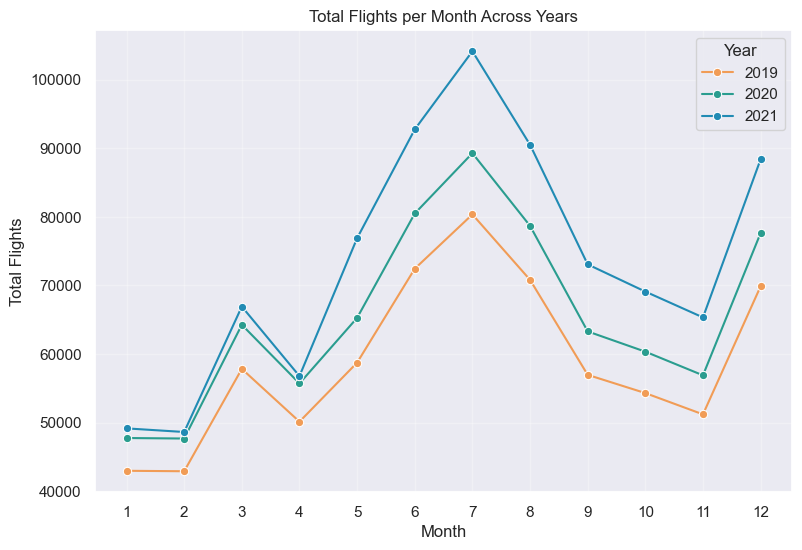

In [69]:
monthly_data = flights_original.groupby(['Year', 'Month'], as_index=False)['NumFlights'].sum()

fig, ax = plt.subplots(figsize=(9,6))   
sns.lineplot(data=monthly_data, x='Month', y='NumFlights', hue='Year', marker='o', palette=["#f19c56", '#2a9d8f', "#218BB4"])
plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Total Flights')
plt.title('Total Flights per Month Across Years')
plt.grid(alpha=0.3)
plt.show()

This line chart shows how total flights fluctuate month by month for 2019–2021, revealing a clear seasonal travel pattern:

- Peak around June–August, coinciding with the summer travel season.
- Smaller surge in December likely driven by holiday travel.
-  Slight rise appears around March–April, corresponding with spring break.

Among the three years, 2019 recorded the lowest flight volumes, 2020 showed moderate activity, and 2021 experienced a sharp increase, likely reflecting AIAI’s business expansion.



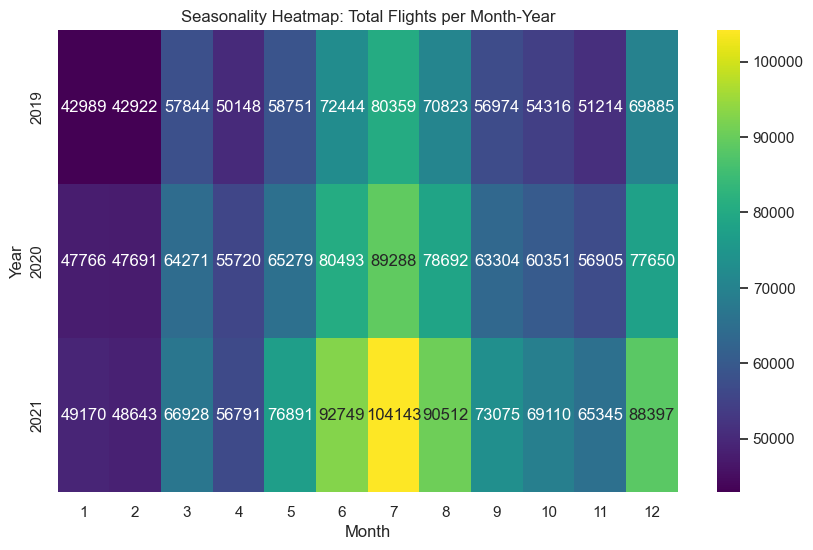

In [70]:
pivot = monthly_data.pivot(index='Year', columns='Month', values='NumFlights')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='viridis', annot=True, fmt='.0f')
plt.title('Seasonality Heatmap: Total Flights per Month-Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()


This heatmap reinforces the insights gotten from the previous graphs, while offering a slightly different perspective on our data.

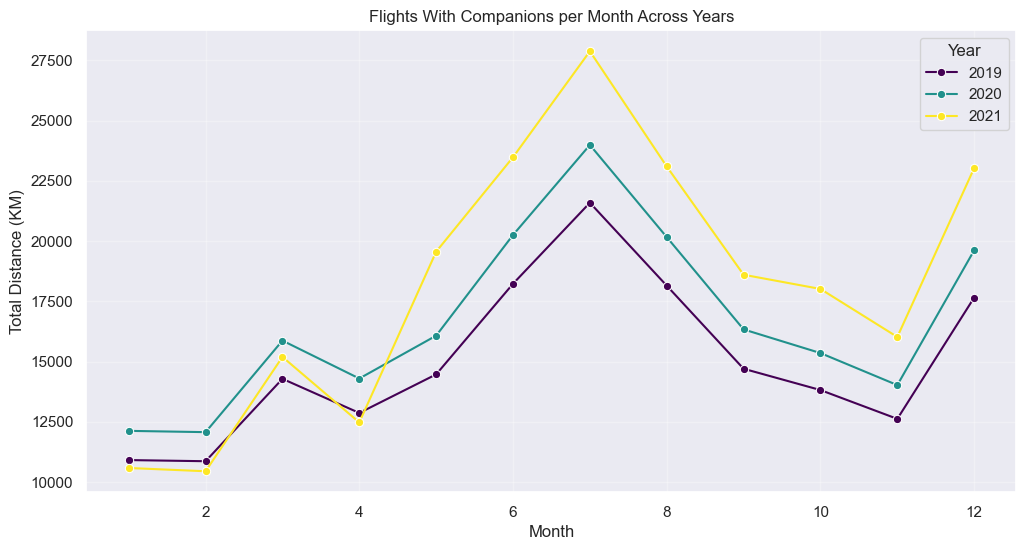

In [71]:
dist_data = flights_original.groupby(['Year', 'Month'], as_index=False)['NumFlightsWithCompanions'].sum()

plt.figure(figsize=(12,6))
sns.lineplot(data=dist_data, x='Month', y='NumFlightsWithCompanions', hue='Year', marker='o', palette='viridis')
plt.title('Flights With Companions per Month Across Years')
plt.xlabel('Month')
plt.ylabel('Total Distance (KM)')
plt.grid(alpha=0.3)
plt.show()


`Flights with companions` also increase duting peak times. Social and leisure travel appear to be key motivators during these peak periods, as travel with companions rises notably in the summer and winter holidays. The slight dip around spring break may reflect the more individual or small-group nature of such trips, which in Canada are often associated with shorter, leisure-focused getaways rather than family travel.  

**However**, its worth noting that despite this increase the peak of flights with companions is only ≈27500, while for total flights its ≈100000. This shows a very small ratio of flights with company, with the majoraty of customers seeming to be lone flyers.

Let's study this matter further:


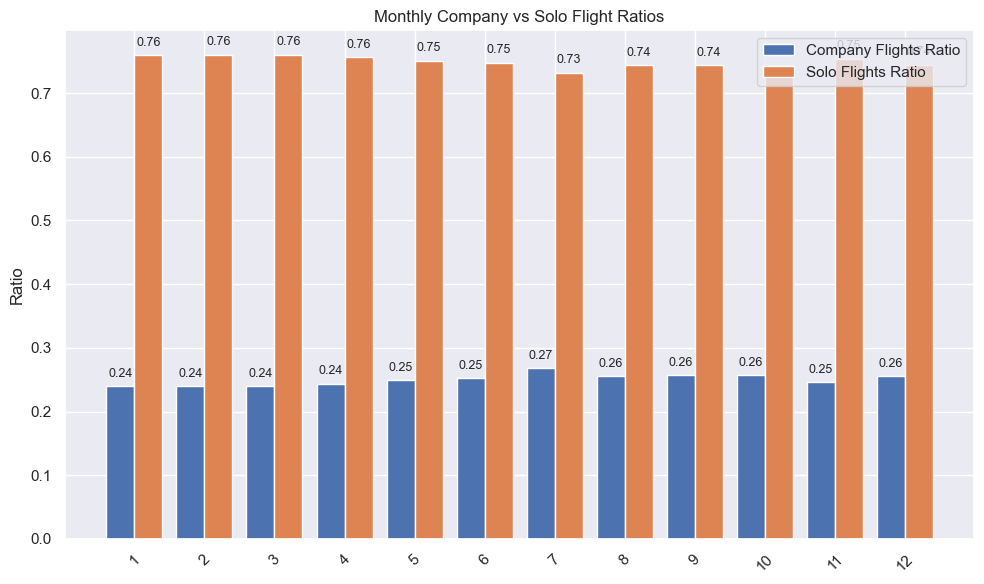

In [72]:
import matplotlib.pyplot as plt

monthly = (
    flights_original.groupby('Month', as_index=False)
    .agg({
        'NumFlights': 'sum',
        'NumFlightsWithCompanions': 'sum'
    })
)

monthly['monthly_companyflights_ratio'] = (
    monthly['NumFlightsWithCompanions'] / monthly['NumFlights']
)
monthly['monthly_soloflights_ratio'] = 1 - monthly['monthly_companyflights_ratio']

plt.figure(figsize=(10, 6))

x = range(len(monthly))

bar1 = plt.bar(
    [i - 0.2 for i in x],
    monthly['monthly_companyflights_ratio'],
    width=0.4,
    label='Company Flights Ratio'
)
bar2 = plt.bar(
    [i + 0.2 for i in x],
    monthly['monthly_soloflights_ratio'],
    width=0.4,
    label='Solo Flights Ratio'
)


for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,           
            f"{height:.2f}",            
            ha='center', va='bottom',
            fontsize=9
        )

# Labels and formatting
plt.xticks(x, monthly['Month'], rotation=45)
plt.ylabel('Ratio')
plt.title('Monthly Company vs Solo Flight Ratios')
plt.legend()
plt.tight_layout()
plt.show()


These findings indicate the possibility that when people fly more (summer, holidays), they also fly solo more this way both rise proportionally, with both ratios staying consistent trough the years.

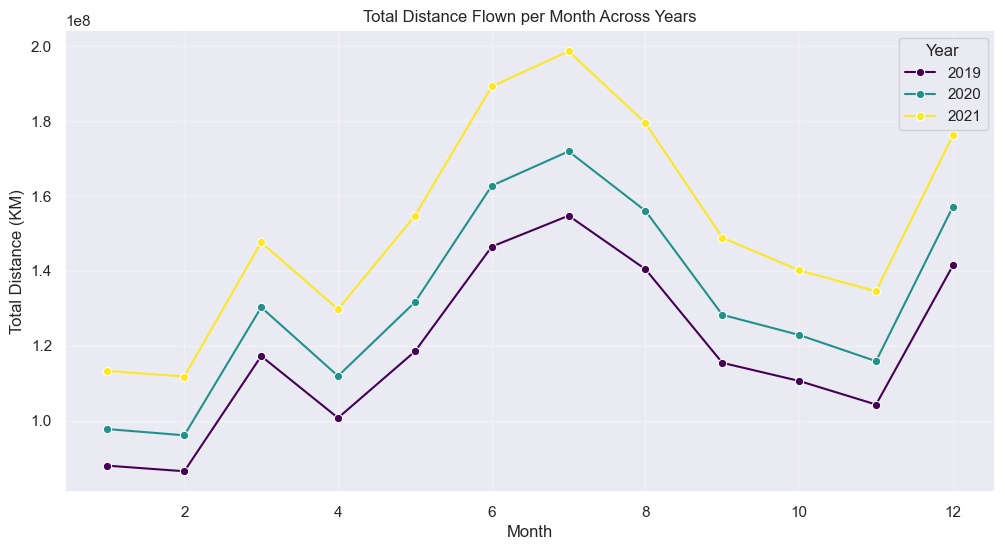

In [73]:
dist_data = flights_original.groupby(['Year', 'Month'], as_index=False)['DistanceKM'].sum()

plt.figure(figsize=(12,6))
sns.lineplot(data=dist_data, x='Month', y='DistanceKM', hue='Year', marker='o', palette='viridis')
plt.title('Total Distance Flown per Month Across Years')
plt.xlabel('Month')
plt.ylabel('Total Distance (KM)')
plt.grid(alpha=0.3)
plt.show()


 Since the increase in distance flown is proportionate to the rise of total flights we can assume that this indicates more flight during the busy seasons, implying more frequent and potentially more fully booked flights during these periods of greater passenger demand.

We can take away a few key insights from our seasonal study:

- Flight counts, distance flown, and companionship travel show a clear seasonal pattern, peaking during Summer, Winter and Spring break.
- The alignment of flight count, distance, and companion trends highlights the increasing customers of AIAI

Eventually, it would be very interesting to study the demographic qualities of those that tend to travel for leisure and those who travel for plesure. Marital Status, Loyalty Status and CLV would probaly offer valuable insights and perhaps show clustering tendencies.

#### 3.4.2 Histograms

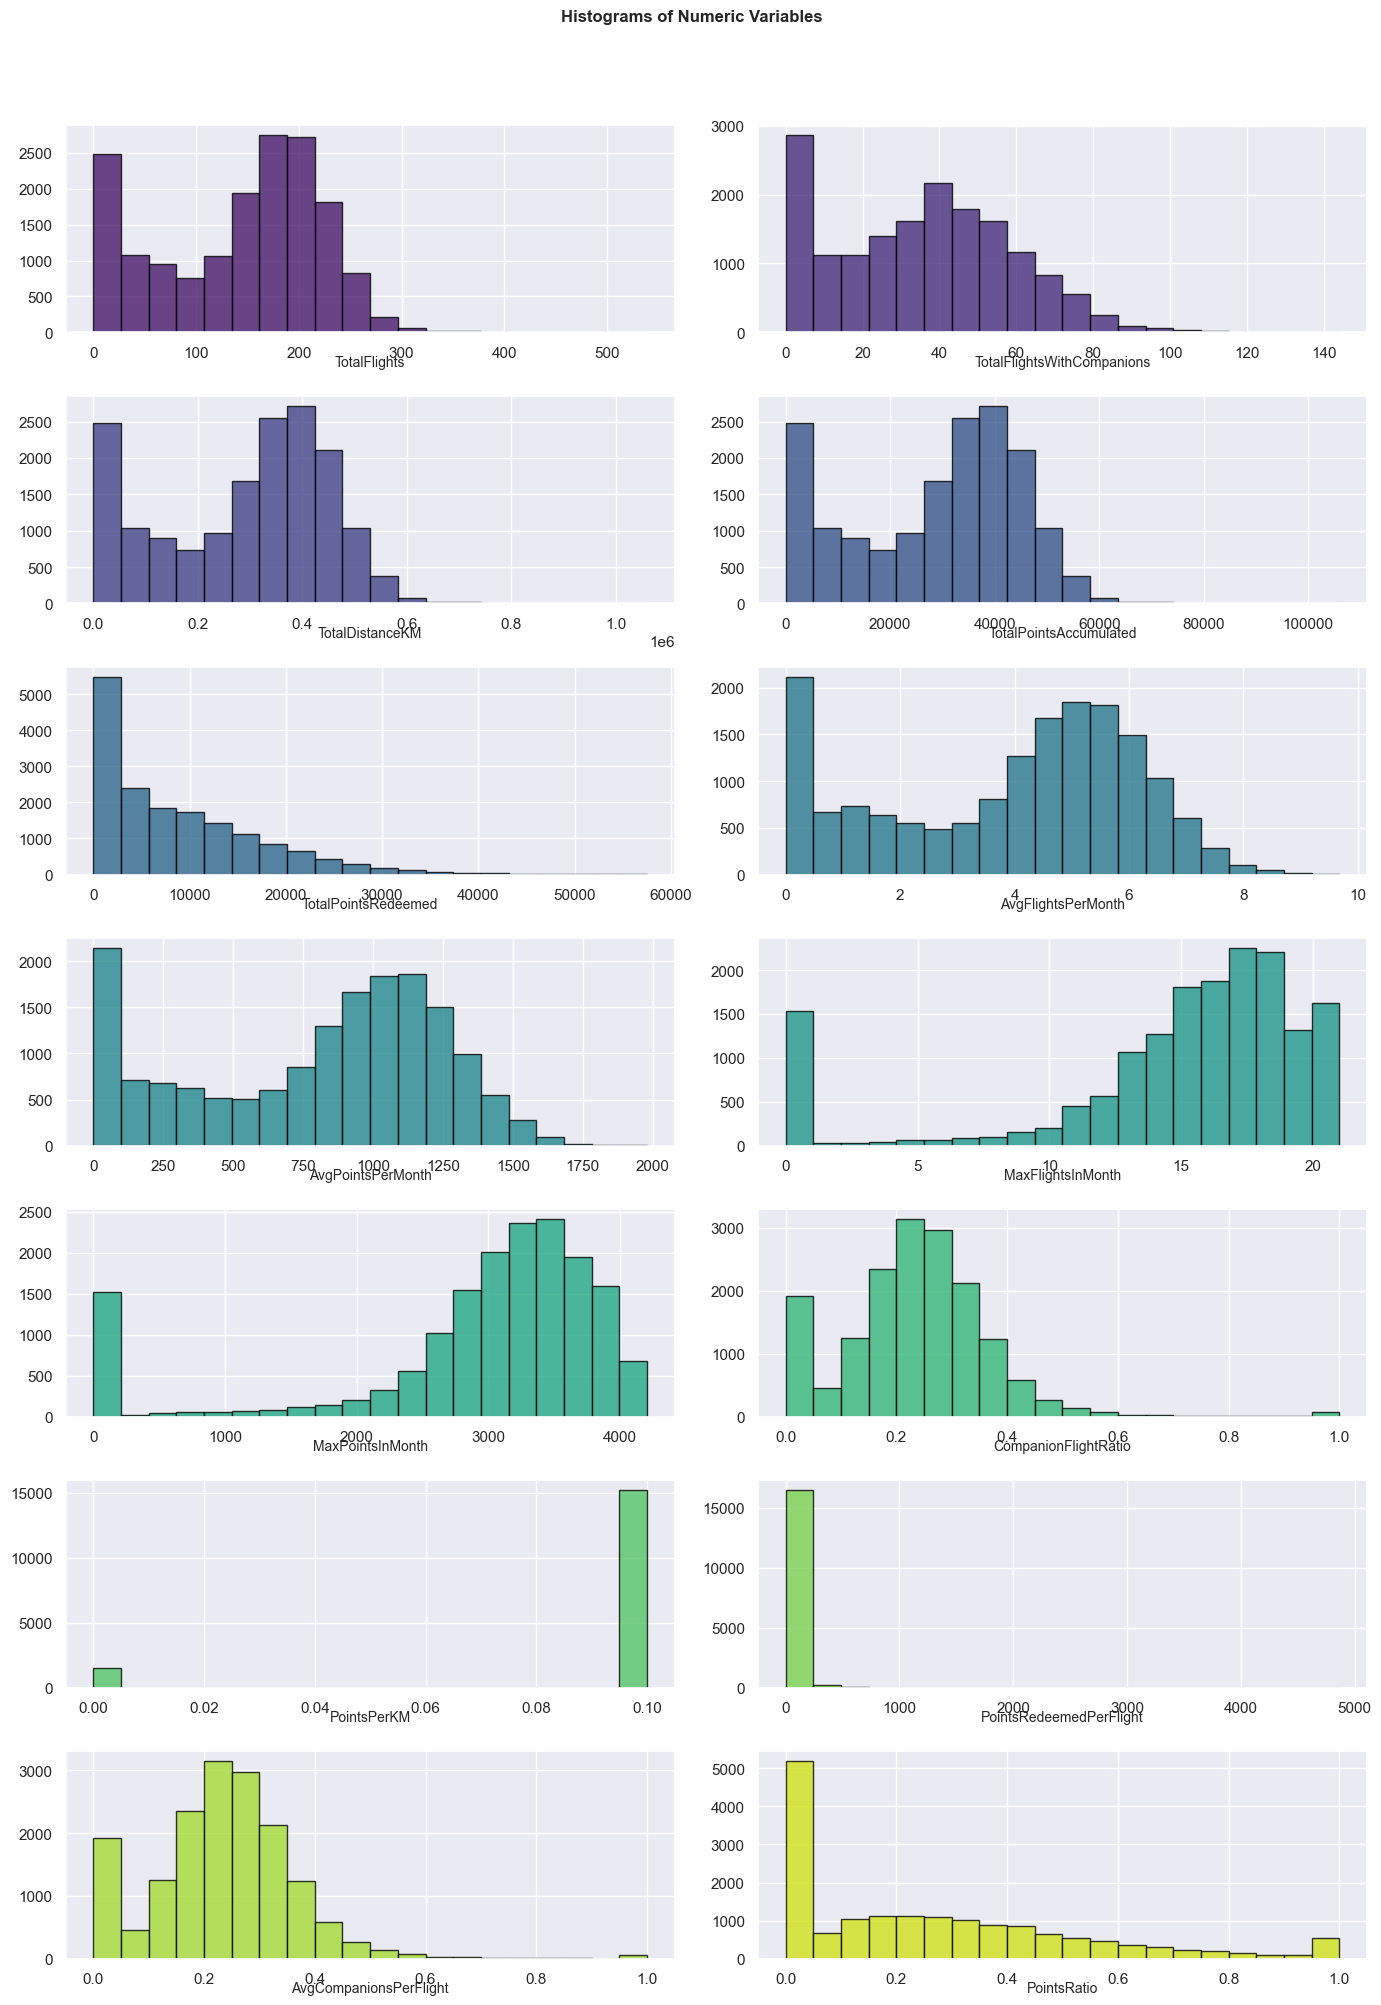

In [74]:
sns.set(style="darkgrid")

metric_features = [
    'TotalFlights', 'TotalFlightsWithCompanions', 'TotalDistanceKM',
    'TotalPointsAccumulated', 'TotalPointsRedeemed', 'AvgFlightsPerMonth',
    'AvgPointsPerMonth', 'MaxFlightsInMonth', 'MaxPointsInMonth',
    'CompanionFlightRatio', 'PointsPerKM', 'PointsRedeemedPerFlight',
    'AvgCompanionsPerFlight', 'PointsRatio'
]

sp_rows = 7
sp_cols = 2

colors = sns.color_palette('viridis', n_colors=len(metric_features))

fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(14, 20))

for ax, feat, color in zip(axes.flatten(), metric_features, colors):
    ax.hist(flights[feat], bins=20, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(feat, y=-0.2, fontsize=10)  

plt.suptitle("Histograms of Numeric Variables", fontsize=12, fontweight='bold', y=1)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


After analyzing the histograms we can say:
- `TotalPointsRedeemed` and `PointsRedeemedPerFlight` exhibit extreme positive (right) skew, with the vast majority of customers having redeemed very few or zero points.
- `TotalFlights`, `TotalFlightsWithCompanions` and `TotalDistanceKM` all show a strong positive (right) skew, indicating that a small number of high-activity customers contribute heavily to the overall totals.
- `AvgFlightsPerMonth` and `AvgPointsPerMonth` display a more moderate, potentially multimodal distribution, suggesting there are distinct groups of low, medium, and high-frequency/accumulation customers.
- `MaxFlightsInMonth` and `MaxPointsInMonth` show a negative (left) skew, with the mode clustered toward the right (higher values), suggesting that most customers reached their peak flight/point activity late in the range of possible monthly values.
- `Companion Flight Ratio` bar plot shows that most customers have a companion flight ratio between 0.1 and 0.3, meaning on average,  ≈25% of flights are taken with a companion. There’s also a small spike at 0, suggesting a portion of customers who never travel with companions.


#### 3.4.3 Boxplots

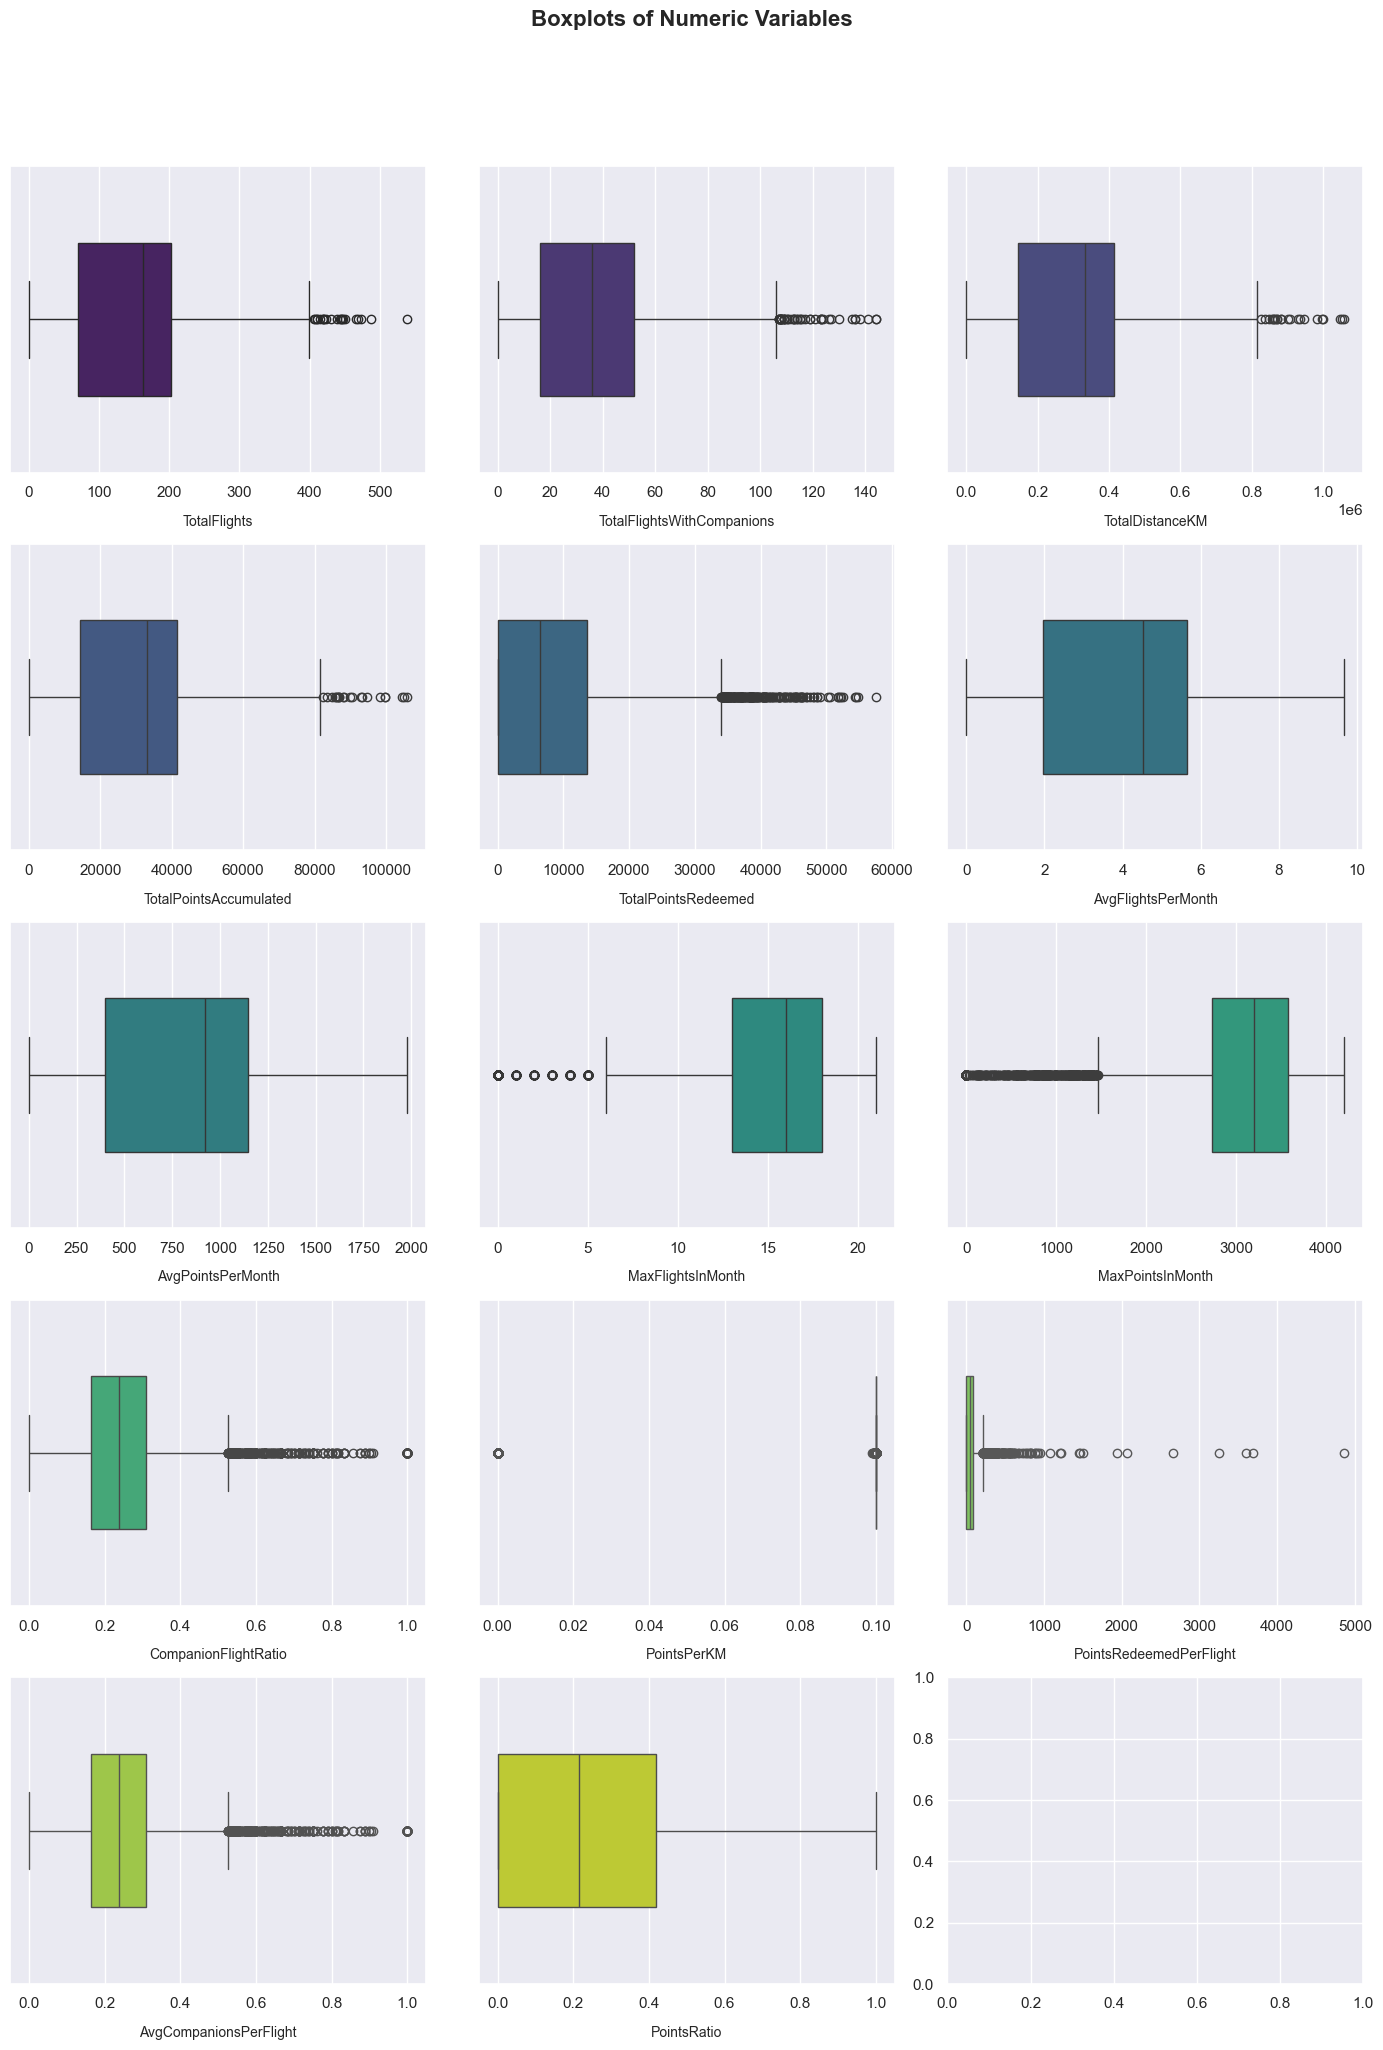

In [75]:
sns.set(style="darkgrid")

metric_features = [
    'TotalFlights', 'TotalFlightsWithCompanions', 'TotalDistanceKM',
    'TotalPointsAccumulated', 'TotalPointsRedeemed', 'AvgFlightsPerMonth',
    'AvgPointsPerMonth', 'MaxFlightsInMonth', 'MaxPointsInMonth',
    'CompanionFlightRatio', 'PointsPerKM', 'PointsRedeemedPerFlight',
    'AvgCompanionsPerFlight', 'PointsRatio'
]

sp_rows = 5
sp_cols = 3

colors = sns.color_palette('viridis', n_colors=len(metric_features))

fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(14, 20))

for ax, feat, color in zip(axes.flatten(), metric_features, colors):
    sns.boxplot(x=flights[feat], color=color, ax=ax, width=0.5)
    ax.set_title(feat, fontsize=10, y=-0.2)
    ax.set_xlabel("")  
    ax.set_ylabel("")  

# Layout
plt.suptitle("Boxplots of Numeric Variables", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

The boxplots show us:
- All Total metrics (`TotalFlights`, `TotalDistanceKM`, `TotalPointsAccumulated`, `TotalPointsRedeemed`) show extreme positive skewness, with the median and interquartile range heavily clustered near zero (or low values) and many significant outliers extending to the maximum values.
- `AvgFlightsPerMonth` and `AvgPointsPerMonth` exhibit a moderate positive skew, with the median located in the lower-middle half of the overall range, but the IQR is wider than the Total metrics, suggesting more variation in average monthly activity.
- `MaxFlightsInMonth` and `MaxPointsInMonth` display a negative (left) skew, as evidenced by the median line being in the upper half of the box and the left whisker (low values) being shorter than the right, meaning the bulk of customers achieved their highest activity near the upper range.
- `PointsPerKM` and `PointsRedeemedPerFlight` have their median and IQR at or very near zero, confirming that most customers either have a standard, very low point-per-km ratio or rarely redeem points per flight.

#### 3.4.4 Correlation Matrix

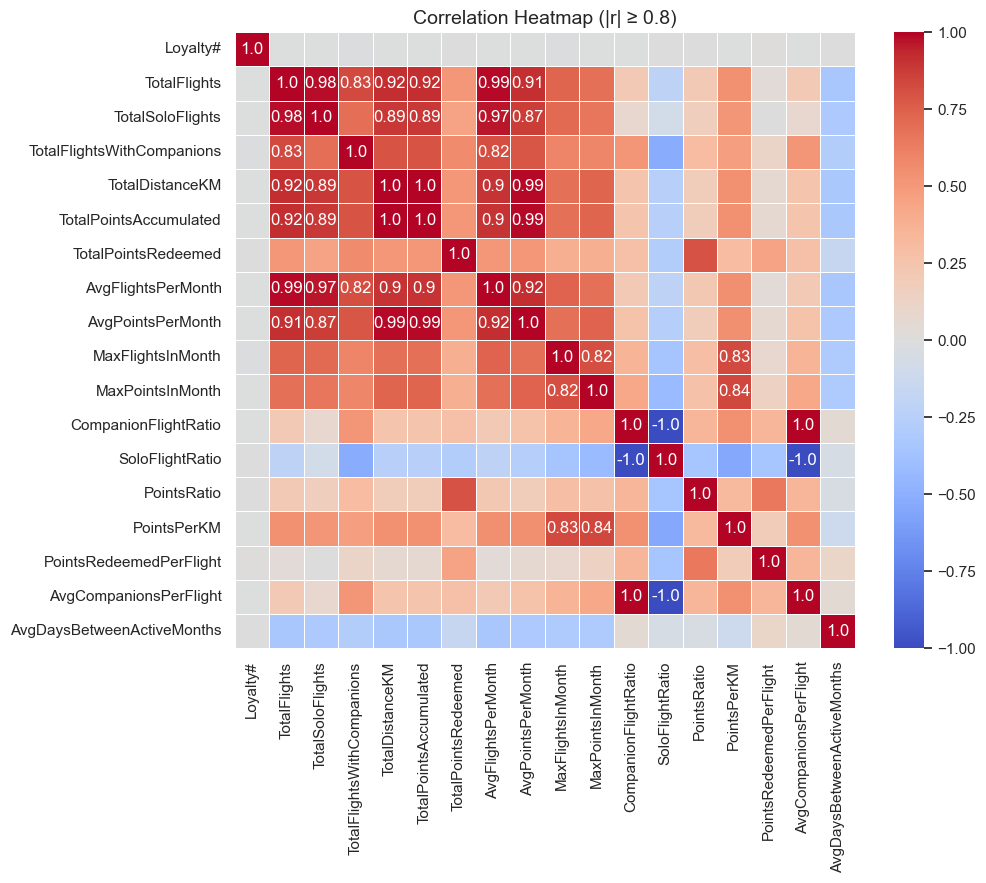

In [76]:
correlation_matrix = flights.corr(method='pearson')

mask_annot = np.abs(correlation_matrix) >= 0.8

annot = np.where(mask_annot, 
                 np.round(correlation_matrix, 2).astype(str), 
                 "")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=annot, 
            fmt="", 
            cmap="coolwarm", 
            center=0,
            linewidths=0.6)

plt.title("Correlation Heatmap (|r| ≥ 0.8)", fontsize=14)
plt.show()


We will drop the features `TotalPointsAccumulated`, `AvgCompanionsPerFlight` and `SoloFlightRatio`, since they are perfect correlated with `TotalDistanceKM` and `CompanionFlightRatio`.

In [77]:
flights = flights.drop(columns=['AvgCompanionsPerFlight', 'SoloFlightRatio'])

In [78]:
flights.describe()

,Loyalty#,TotalFlights,TotalSoloFlights,TotalFlightsWithCompanions,TotalDistanceKM,TotalPointsAccumulated,TotalPointsRedeemed,AvgFlightsPerMonth,AvgPointsPerMonth,MaxFlightsInMonth,MaxPointsInMonth,CompanionFlightRatio,PointsRatio,PointsPerKM,PointsRedeemedPerFlight,AvgDaysBetweenActiveMonths
count,16737.000000,16737.000000,16737.000000,16737.000000,1.673700e+04,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,14954.000000
mean,549735.880445,141.724025,106.301356,35.424568,2.886169e+05,28856.006327,8552.045767,3.921322,796.312690,14.479118,2901.512398,0.235125,0.266047,0.091035,58.148315,48.849892
std,258912.132453,81.968108,63.741496,23.665787,1.669163e+05,16688.825594,8751.750064,2.239389,454.392711,5.479532,1085.599803,0.135974,0.266446,0.028533,96.557819,26.632163
min,100018.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326603.000000,70.000000,52.000000,16.000000,1.440810e+05,14405.000000,0.000000,1.952778,399.527778,13.000000,2731.000000,0.163934,0.000000,0.099974,0.000000,39.444444
50%,550434.000000,163.000000,118.200000,36.000000,3.315894e+05,33152.440000,6519.000000,4.519444,920.159444,16.000000,3202.000000,0.237791,0.215097,0.099979,43.625763,44.375000
75%,772019.000000,203.000000,153.800000,52.000000,4.139942e+05,41393.520000,13607.200000,5.638889,1147.265000,18.000000,3576.000000,0.308725,0.419533,0.099983,85.416979,51.000000
max,999986.000000,539.000000,404.000000,144.000000,1.059681e+06,105951.600000,57527.800000,9.677778,1979.568333,21.000000,4204.000000,1.000000,1.000000,0.100000,4865.000000,366.000000


#### 3.4.5 Scatterplots

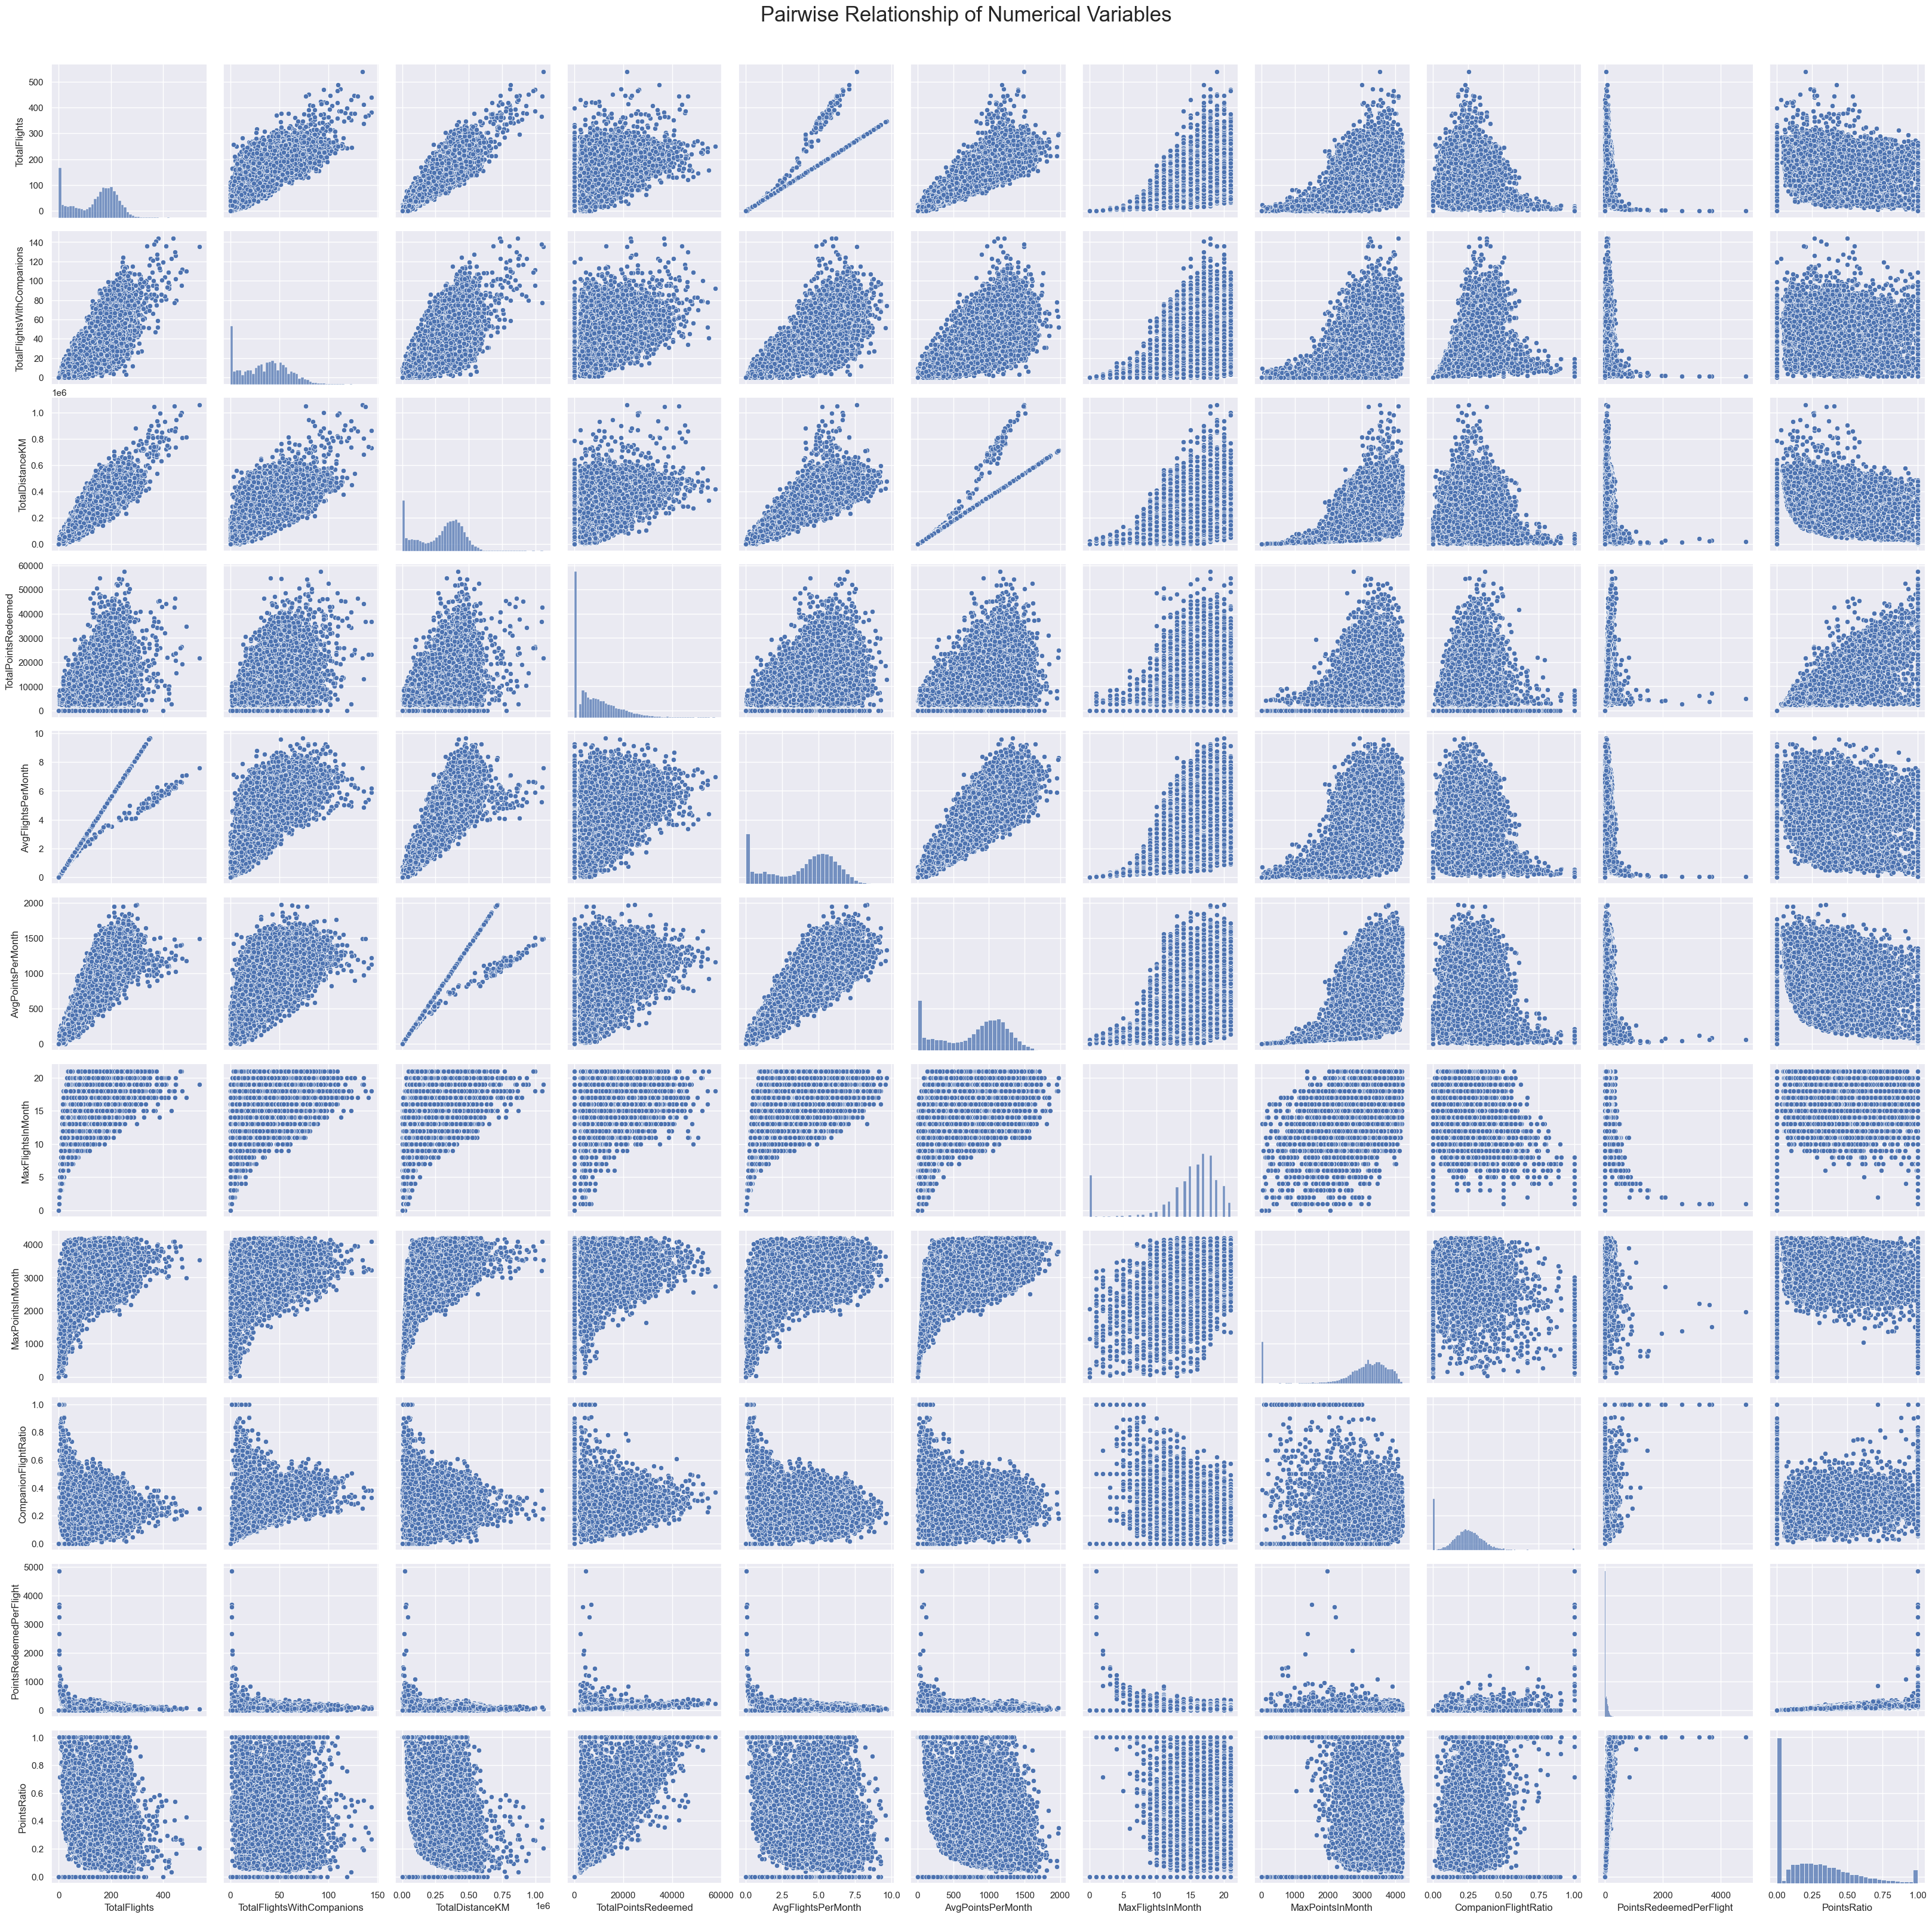

In [79]:
metric_features1 = ['TotalFlights', 'TotalFlightsWithCompanions',
       'TotalDistanceKM', 'TotalPointsRedeemed', 'AvgFlightsPerMonth',
       'AvgPointsPerMonth', 'MaxFlightsInMonth', 'MaxPointsInMonth',
       'CompanionFlightRatio', 'PointsRedeemedPerFlight','PointsRatio']
sns.pairplot(
    flights[metric_features1],
    diag_kind="hist",   
    height=3,           
    aspect=1            
)

plt.subplots_adjust(top=0.95)
plt.suptitle("Pairwise Relationship of Numerical Variables", fontsize=25)
plt.show()

With this scatterplots we can say:
With this scatterplots we can say:
- `TotalFlights`, `TotalFlightsWithCompanions` and `TotalDistanceKM` all show a very strong positive linear relationships, indicating that high activity in any one of these areas strongly predicts high activity in the others
-  The average monthly metrics (`AvgFlightsPerMonth` and `AvgPointsPerMonth`) show a near-perfect correlation with their respective Total metrics, which is expected since the number of active months is constant (36).
- `TotalPointsRedeemed` and `PointsRedeemedPerFlight` show only moderate positive correlations with most activity metrics, indicating that high flight volume or distance doesn't guarantee high redemption. 
- The peak monthly activities, `MaxFlightsInMonth` and `MaxPointsInMonth`, are strongly and positively correlated, suggesting that customers tend to have their maximum flight volume and maximum point accumulation in the same months.

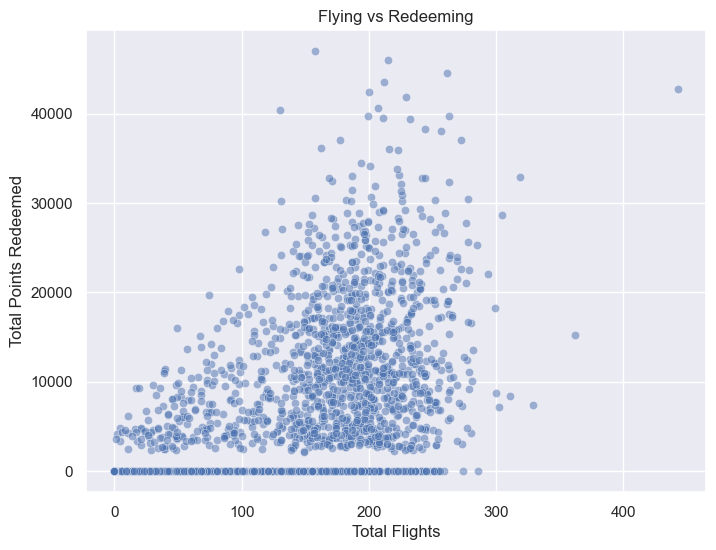

In [80]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=flights.sample(n=2000, random_state=42),
    x='TotalFlights', y='TotalPointsRedeemed', alpha=0.5
)
plt.title("Flying vs Redeeming")
plt.xlabel("Total Flights")
plt.ylabel("Total Points Redeemed")
plt.show()


One very interesting aspect taken from the above plots is that there seems to be a positive but weak correlation between the `number of flights` and `total points redeemed`, meaning that, generally, customers who fly more tend to redeem more points. However, the data shows a large cluster near zero redemptions, even for customers with many flights. This suggests that many frequent flyers accumulate points but do not redeem them often.

For those that have flown many times, there seems to be a big interval in points redeemed as some spend a lot and others spend none.

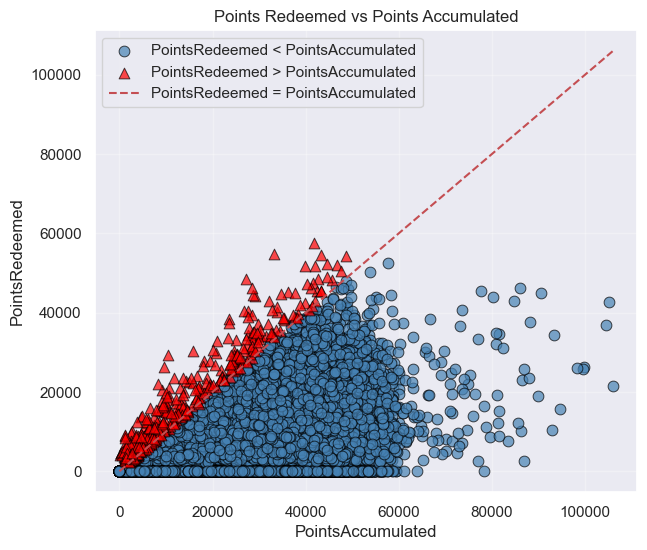

In [81]:
x = flights['TotalPointsAccumulated']
y = flights['TotalPointsRedeemed']

above = y > x
below = ~above

plt.figure(figsize=(7,6))

plt.scatter(
    x[below], y[below],
    s=60,
    marker='o',
    edgecolors='black',
    linewidth=0.7,
    color='steelblue',
    alpha=0.7,
    label='PointsRedeemed < PointsAccumulated'
)

plt.scatter(
    x[above], y[above],
    s=60,
    marker='^',                
    edgecolors='black',
    linewidth=0.7,
    color='red',
    alpha=0.7,
    label='PointsRedeemed > PointsAccumulated'
)

plt.plot([0, max(x)], [0, max(x)], 'r--', label='PointsRedeemed = PointsAccumulated')

plt.xlabel('PointsAccumulated')
plt.ylabel('PointsRedeemed')
plt.title('Points Redeemed vs Points Accumulated')
plt.legend()
plt.grid(alpha=0.3)            
plt.show()

The customers above the `x=y` line are the ones that redeemed more points than they accumulated. We can look at them as potential outliers, as those are the 458 customers we mentioned before. Maybe with the data in the customers dataset we can understand better why this happened.

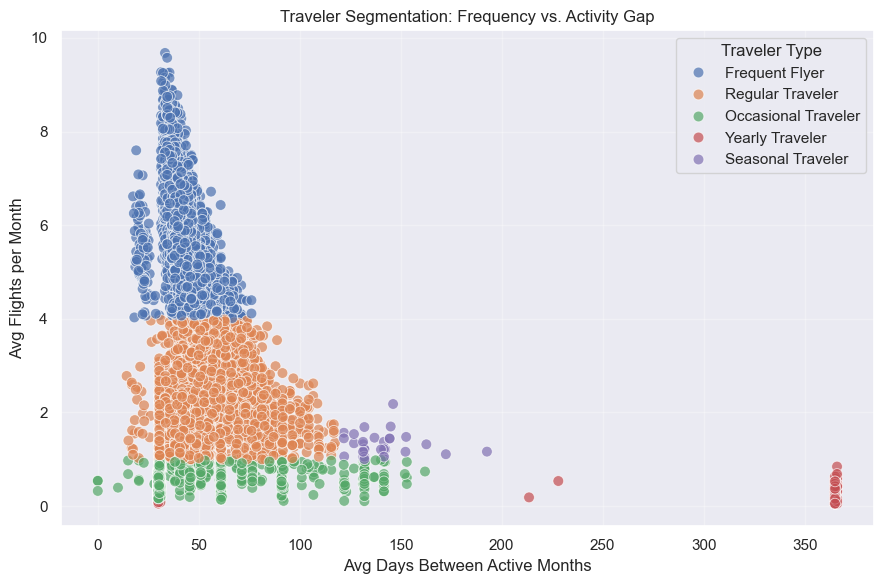

In [82]:
def classify_traveler(row):
    # Frequent Flyers: weekly or more
    if row['AvgFlightsPerMonth'] >= 4:
        return 'Frequent Flyer'
    
    # Regular Travelers: monthly to biweekly, consistent
    elif 1 <= row['AvgFlightsPerMonth'] < 4 and row['AvgDaysBetweenActiveMonths'] < 120:
        return 'Regular Traveler'
    
    # Seasonal Travelers: travel bursts separated by long gaps
    elif 1 <= row['AvgFlightsPerMonth'] < 4 and row['AvgDaysBetweenActiveMonths'] >= 120:
        return 'Seasonal Traveler'
    
    # Occasional Travelers: a few times per year
    elif 0.1 <= row['AvgFlightsPerMonth'] < 1 and row['AvgDaysBetweenActiveMonths'] < 200:
        return 'Occasional Traveler'
    
    # Yearly Travelers: very rare, highly seasonal
    elif row['AvgFlightsPerMonth'] < 0.1 or row['AvgDaysBetweenActiveMonths'] >= 200:
        return 'Yearly Traveler'


flights['TravelerType'] = flights.apply(classify_traveler, axis=1)



plt.subplots(figsize=(9,6))   
 
sns.scatterplot(
    data=flights,
    x='AvgDaysBetweenActiveMonths',
    y='AvgFlightsPerMonth',
    hue='TravelerType',
    alpha=0.7,
    s=60
)
plt.title('Traveler Segmentation: Frequency vs. Activity Gap')
plt.xlabel('Avg Days Between Active Months')
plt.ylabel('Avg Flights per Month')
plt.legend(title='Traveler Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


For this scatter plot we have used `AvgFlightsPerMonth`  to capture how much customers fly and `AvgDaysBetweenActiveMonths` in order to capture how regularly they do so.

The thresholds used to classify traveler types were manually defined based on both industry benchmarks and behavioral interpretation of the data:

- 4 flights per month : corresponds to roughly one flight per week, a standard marker of a frequent flyer in loyalty programs (≈ 40–60 flights per year).

- 1 flight/month boundary aligns directly with a natural behavioral unit (monthly travel).

- 90 days between active months — represents a quarterly gap in travel activity. Customers whose average interval between flying months exceeds 90 days typically fly only during holidays or vacation seasons.

These thresholds are meant to reflect realistic travel behaviors observed in the data distribution and in the airline industries.

This scatter plot offers a good insights.

- A strong negative correlation  (with the increase of average days between active months, average flights per month drop sharply). Which confirms distinct behavioral differences rather than random variation..

Future clustering opportunities show:

- Frequent Flyers (top-left cluster): shortest gaps (<50 days) and high volume (4–10 flights/month).

- Regular Travelers (orange cluster): moderate gaps (≈ 40–90 days) and 2–4 flights/month, representing a stable core 

- Occasional Travelers (green cluster) : few flights per month, but not extremely seasonal.

- Vacation Flyers (red cluster): long gaps (90–350+ days) and 1–2 flights/month when active.


**In the future we will merge this info with the demographic features and with our seasonality overview.**

### 3.5 Checking outliers

We noticed that the outliers are a big part of our that set, so it's necessary to check if there is a significant presence of them, to avoid their potential negative impact on our analysis.

In [83]:
numeric_only = flights.select_dtypes(include=[np.number])
q1 = numeric_only.quantile(0.25)
q3 = numeric_only.quantile(0.75)
iqr = q3 - q1
outliers = ((numeric_only < (q1 - 1.5 * iqr)) | (numeric_only > (q3 + 1.5 * iqr))).sum()
outliers

Loyalty#                         0
TotalFlights                    21
TotalSoloFlights                22
TotalFlightsWithCompanions      44
TotalDistanceKM                 22
TotalPointsAccumulated          22
TotalPointsRedeemed            199
AvgFlightsPerMonth               0
AvgPointsPerMonth                0
MaxFlightsInMonth             1697
MaxPointsInMonth              1836
CompanionFlightRatio           315
PointsRatio                      0
PointsPerKM                   2173
PointsRedeemedPerFlight        370
AvgDaysBetweenActiveMonths    1043
dtype: int64

We will check if there is a significant presence of outliers in the dataset, to avoid their potential negative impact on our analysis.

In [84]:
outlier_mask = ((numeric_only <= (q1 - 1.5 * iqr)) | (numeric_only >= (q3 + 1.5 * iqr)))
outlier_rows = outlier_mask.any(axis=1)
num_outlier_rows = outlier_rows.sum()

print(f"The presence of outliers is {(num_outlier_rows/len(flights))*100:.2f}% of the dataset.")


The presence of outliers is 22.29% of the dataset.


The amount of outliers of this data would affect only 17.74% of the dataset, so we have to tak care of them in feature analysis.

# Merge datasets

In [85]:
customers

,Loyalty#,Province or State,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,IsCanceled,ProgramDaysDuration
0,480934,Ontario,female,Bachelor,Urban,70146.0,Married,Star,3839.14,Standard,0,1416.0
1,549612,Alberta,male,College,Rural,0.0,Divorced,Star,3839.61,Standard,0,1394.0
2,429460,British Columbia,male,College,Urban,0.0,Single,Star,3839.75,Standard,1,1274.0
3,608370,Ontario,male,College,Suburban,0.0,Single,Star,3839.75,Standard,0,2510.0
4,530508,Quebec,male,Bachelor,Suburban,97832.0,Married,Star,3842.79,2021 Promotion,0,1894.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16896,823768,British Columbia,female,College,Rural,0.0,Married,Star,61850.19,Standard,0,2567.0
16897,680886,Saskatchewan,female,Bachelor,Rural,78310.0,Married,Star,67907.27,Standard,0,1943.0
16898,776187,British Columbia,male,College,Urban,0.0,Single,Star,74228.52,Standard,0,2109.0
16899,615459,Quebec,male,Bachelor,Urban,58958.0,Married,Star,83325.38,2021 Promotion,1,244.0


In [86]:
flights_original = flights_original.drop(columns=['YearMonthDate'])
flights_original

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,2.0,2.0,9384.0,938.00,0.0,0.0
1,464105,2021,12,0.0,0.0,0.0,0.00,0.0,0.0
2,681785,2021,12,10.0,3.0,14745.0,1474.00,0.0,0.0
3,185013,2021,12,16.0,4.0,26311.0,2631.00,3213.0,32.0
4,216596,2021,12,9.0,0.0,19275.0,1927.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...
608431,999902,2019,12,7.2,0.0,30766.5,3076.65,0.0,0.0
608432,999911,2019,12,0.0,0.0,0.0,0.00,0.0,0.0
608433,999940,2019,12,14.4,0.9,18261.0,1826.10,0.0,0.0
608434,999982,2019,12,0.0,0.0,0.0,0.00,0.0,0.0


In [87]:
# Create monthly aggregation with 12 dummy variables for month averages
# Group by Loyalty# and aggregate: sum for most variables, mean for NumFlights by month

# First, create a pivot table with average NumFlights per month
monthly_avg = flights_original.pivot_table(
    index='Loyalty#', 
    columns='Month', 
    values='NumFlights', 
    aggfunc='mean',
    fill_value=0
)

# Rename columns to be more descriptive
monthly_avg.columns = [f'Avg_Flights_Month_{int(month)}' for month in monthly_avg.columns]

# Group by Loyalty# and sum all other variables
flights_agg = flights_original.groupby('Loyalty#').agg({
    'NumFlights': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum'
})

# Merge the monthly averages with the aggregated data
flights_with_monthly_avg = flights_agg.join(monthly_avg, on='Loyalty#')

flights = flights_with_monthly_avg

In [88]:
dataset_final = pd.merge(customers, flights, on='Loyalty#', how='inner')
dataset_final

,Loyalty#,Province or State,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,...,Avg_Flights_Month_3,Avg_Flights_Month_4,Avg_Flights_Month_5,Avg_Flights_Month_6,Avg_Flights_Month_7,Avg_Flights_Month_8,Avg_Flights_Month_9,Avg_Flights_Month_10,Avg_Flights_Month_11,Avg_Flights_Month_12
0,480934,Ontario,female,Bachelor,Urban,70146.0,Married,Star,3839.14,Standard,...,0.666667,4.333333,10.566667,7.933333,10.066667,10.200000,5.600000,2.633333,5.066667,2.900000
1,549612,Alberta,male,College,Rural,0.0,Divorced,Star,3839.61,Standard,...,10.533333,3.333333,14.133333,4.000000,11.933333,12.133333,3.333333,9.266667,6.966667,3.666667
2,429460,British Columbia,male,College,Urban,0.0,Single,Star,3839.75,Standard,...,5.066667,0.000000,7.600000,0.000000,0.000000,6.966667,5.066667,0.000000,5.066667,0.633333
3,608370,Ontario,male,College,Suburban,0.0,Single,Star,3839.75,Standard,...,10.166667,4.433333,7.966667,12.166667,0.000000,0.000000,6.333333,7.466667,0.633333,5.500000
4,530508,Quebec,male,Bachelor,Suburban,97832.0,Married,Star,3842.79,2021 Promotion,...,1.333333,0.000000,8.100000,4.966667,6.933333,12.533333,2.600000,0.000000,8.100000,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16712,823768,British Columbia,female,College,Rural,0.0,Married,Star,61850.19,Standard,...,0.000000,5.700000,1.333333,6.000000,9.466667,5.700000,7.500000,3.666667,0.000000,9.366667
16713,680886,Saskatchewan,female,Bachelor,Rural,78310.0,Married,Star,67907.27,Standard,...,6.333333,6.966667,8.766667,4.666667,14.166667,3.666667,12.200000,3.666667,10.966667,5.000000
16714,776187,British Columbia,male,College,Urban,0.0,Single,Star,74228.52,Standard,...,9.266667,5.433333,7.100000,15.533333,7.033333,12.133333,6.333333,2.600000,8.733333,5.333333
16715,615459,Quebec,male,Bachelor,Urban,58958.0,Married,Star,83325.38,2021 Promotion,...,0.000000,0.000000,0.000000,4.333333,4.000000,2.666667,2.333333,0.000000,4.333333,0.000000


In [89]:
dataset_final.duplicated().sum()

0

In [90]:
dataset_final.isna().sum()

Loyalty#                    0
Province or State           0
Gender                      0
Education                   0
Location Code               0
Income                      0
Marital Status              0
LoyaltyStatus               0
Customer Lifetime Value     0
EnrollmentType              0
IsCanceled                  0
ProgramDaysDuration         2
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
Avg_Flights_Month_1         0
Avg_Flights_Month_2         0
Avg_Flights_Month_3         0
Avg_Flights_Month_4         0
Avg_Flights_Month_5         0
Avg_Flights_Month_6         0
Avg_Flights_Month_7         0
Avg_Flights_Month_8         0
Avg_Flights_Month_9         0
Avg_Flights_Month_10        0
Avg_Flights_Month_11        0
Avg_Flights_Month_12        0
dtype: int64

In [91]:
dataset_final.dropna(inplace=True)

In [93]:
#dataset_final.to_csv('dataset_final.csv', index=False)

In [94]:
dataset_final['Location Code']

0           Urban
1           Rural
2           Urban
3        Suburban
4        Suburban
           ...   
16712       Rural
16713       Rural
16714       Urban
16715       Urban
16716    Suburban
Name: Location Code, Length: 16715, dtype: object

In [95]:
dataset_final.corr(numeric_only=True)

,Loyalty#,Income,Customer Lifetime Value,IsCanceled,ProgramDaysDuration,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,...,Avg_Flights_Month_3,Avg_Flights_Month_4,Avg_Flights_Month_5,Avg_Flights_Month_6,Avg_Flights_Month_7,Avg_Flights_Month_8,Avg_Flights_Month_9,Avg_Flights_Month_10,Avg_Flights_Month_11,Avg_Flights_Month_12
Loyalty#,1.000000,-0.008146,-0.000574,0.002370,-0.008540,-0.004398,-0.009867,-0.005027,-0.005027,0.003081,...,-0.010902,0.001416,0.006978,-0.014870,-0.005733,-0.001073,-0.004502,-0.001213,0.003842,0.006112
Income,-0.008146,1.000000,0.022439,-0.000778,0.004488,-0.004499,-0.004997,-0.000010,-0.000010,-0.010401,...,-0.007394,-0.010541,-0.001759,-0.001630,-0.001934,0.002955,-0.003803,0.001968,0.006961,-0.010538
Customer Lifetime Value,-0.000574,0.022439,1.000000,0.009577,-0.004779,-0.005379,-0.009628,-0.010152,-0.010153,-0.004504,...,-0.005018,-0.009526,-0.003788,-0.009206,-0.001903,-0.006814,0.009040,-0.008981,-0.005122,0.004120
IsCanceled,0.002370,-0.000778,0.009577,1.000000,-0.453654,-0.466239,-0.405315,-0.471834,-0.471817,-0.263645,...,-0.238133,-0.252727,-0.262719,-0.268136,-0.281185,-0.280828,-0.300259,-0.307170,-0.317287,-0.337321
ProgramDaysDuration,-0.008540,0.004488,-0.004779,-0.453654,1.000000,0.609338,0.531902,0.612141,0.612133,0.342909,...,0.402929,0.397175,0.378191,0.370144,0.372822,0.348819,0.338373,0.317352,0.318502,0.296422
NumFlights,-0.004398,-0.004499,-0.005379,-0.466239,0.609338,1.000000,0.830231,0.918049,0.918035,0.513492,...,0.590947,0.584487,0.600525,0.612677,0.633069,0.597922,0.571425,0.542673,0.525348,0.537612
NumFlightsWithCompanions,-0.009867,-0.004997,-0.009628,-0.405315,0.531902,0.830231,1.000000,0.796684,0.796672,0.567035,...,0.482436,0.488905,0.498154,0.506671,0.525156,0.490139,0.473888,0.455141,0.431588,0.443482
DistanceKM,-0.005027,-0.000010,-0.010152,-0.471834,0.612141,0.918049,0.796684,1.000000,1.000000,0.514382,...,0.545970,0.543469,0.552977,0.548859,0.570716,0.540149,0.521277,0.499905,0.482090,0.482661
PointsAccumulated,-0.005027,-0.000010,-0.010153,-0.471817,0.612133,0.918035,0.796672,1.000000,1.000000,0.514375,...,0.545962,0.543461,0.552970,0.548853,0.570711,0.540142,0.521267,0.499894,0.482078,0.482652
PointsRedeemed,0.003081,-0.010401,-0.004504,-0.263645,0.342909,0.513492,0.567035,0.514382,0.514375,1.000000,...,0.308656,0.318896,0.305044,0.302561,0.325853,0.301695,0.291217,0.278419,0.259866,0.264038


In [96]:
dataset_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16715 entries, 0 to 16716
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Loyalty#                  16715 non-null  int64  
 1   Province or State         16715 non-null  object 
 2   Gender                    16715 non-null  object 
 3   Education                 16715 non-null  object 
 4   Location Code             16715 non-null  object 
 5   Income                    16715 non-null  float64
 6   Marital Status            16715 non-null  object 
 7   LoyaltyStatus             16715 non-null  object 
 8   Customer Lifetime Value   16715 non-null  float64
 9   EnrollmentType            16715 non-null  object 
 10  IsCanceled                16715 non-null  int64  
 11  ProgramDaysDuration       16715 non-null  float64
 12  NumFlights                16715 non-null  float64
 13  NumFlightsWithCompanions  16715 non-null  float64
 14  DistanceKM 

In [97]:
non_metric_features = dataset_final.select_dtypes(include=['object']).columns.tolist()
non_metric_features

['Province or State',
 'Gender',
 'Education',
 'Location Code',
 'Marital Status',
 'LoyaltyStatus',
 'EnrollmentType']

In [98]:
metric_features = dataset_final.select_dtypes(include=[np.number]).columns.tolist()
metric_features

['Loyalty#',
 'Income',
 'Customer Lifetime Value',
 'IsCanceled',
 'ProgramDaysDuration',
 'NumFlights',
 'NumFlightsWithCompanions',
 'DistanceKM',
 'PointsAccumulated',
 'PointsRedeemed',
 'Avg_Flights_Month_1',
 'Avg_Flights_Month_2',
 'Avg_Flights_Month_3',
 'Avg_Flights_Month_4',
 'Avg_Flights_Month_5',
 'Avg_Flights_Month_6',
 'Avg_Flights_Month_7',
 'Avg_Flights_Month_8',
 'Avg_Flights_Month_9',
 'Avg_Flights_Month_10',
 'Avg_Flights_Month_11',
 'Avg_Flights_Month_12']

# Encoding categorical variables

In [99]:
dataset_final['Province or State'].unique() #frequency encoding

array(['Ontario', 'Alberta', 'British Columbia', 'Quebec', 'Yukon',
       'New Brunswick', 'Manitoba', 'Nova Scotia', 'Saskatchewan',
       'Newfoundland', 'Prince Edward Island'], dtype=object)

In [100]:
dataset_final['Marital Status'].unique() #one hot encoding

array(['Married', 'Divorced', 'Single'], dtype=object)

In [101]:
dataset_final['Location Code'].unique() #binary encoding

array(['Urban', 'Rural', 'Suburban'], dtype=object)

In [102]:
dataset_final['Gender'].unique() #binary encoding

array(['female', 'male'], dtype=object)

In [103]:
dataset_final['EnrollmentType'].unique() #binary encoding

array(['Standard', '2021 Promotion'], dtype=object)

In [104]:
dataset_final['Education'].unique() #ordinal encoding

array(['Bachelor', 'College', 'Master', 'High School or Below', 'Doctor'],
      dtype=object)

In [105]:
dataset_final['LoyaltyStatus'].unique() #ordinal encoding

array(['Star', 'Aurora', 'Nova'], dtype=object)

In [106]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# Create a copy for encoding to preserve original
dataset_encoded = dataset_final.copy()

# 1. ONE-HOT ENCODING for: Marital Status
one_hot_cols = ['Marital Status']
dataset_encoded = pd.get_dummies(dataset_encoded, columns=one_hot_cols, drop_first=False, prefix=one_hot_cols)

# 2. BINARY ENCODING for: Gender, EnrollmentType, Location Code
# Map to 0/1
binary_mappings = {
    'Gender': {'male': 1, 'female': 0},
    'EnrollmentType': {'Standard': 0, '2021 Promotion': 1},
    'Location Code': {'Urban': 0, 'Suburban': 1, 'Rural': 2}
}

for col, mapping in binary_mappings.items():
    if col in dataset_encoded.columns:
        dataset_encoded[col] = dataset_encoded[col].map(mapping)

# 3. ORDINAL ENCODING for: Education, LoyaltyStatus
# Define ordinal order (from lowest to highest)
ordinal_mappings = {
    'Education': ['High School or below', 'College', "Bachelor's", "Master's", 'Doctorate'],
    'LoyaltyStatus': ['Star', 'Nova', 'Aurora']
}

ordinal_encoder = OrdinalEncoder(categories=[ordinal_mappings[col] for col in ordinal_mappings.keys()], 
                                   handle_unknown='use_encoded_value', unknown_value=-1)

ordinal_cols = list(ordinal_mappings.keys())
dataset_encoded[ordinal_cols] = ordinal_encoder.fit_transform(dataset_encoded[ordinal_cols])

# Rename ordinal columns for clarity
dataset_encoded.rename(columns={
    'Education': 'Education_Ordinal',
    'LoyaltyStatus': 'LoyaltyStatus_Ordinal'
}, inplace=True)

# 4. FREQUENCY ENCODING for: Province or State
freq_encoding = dataset_encoded['Province or State'].value_counts(normalize=True)
dataset_encoded['Province or State_FreqEnc'] = dataset_encoded['Province or State'].map(freq_encoding)

print("✓ Encoding completed!")
print(f"\nDataset shape after encoding: {dataset_encoded.shape}")
print(f"\nNew columns created from one-hot encoding:")
one_hot_cols_created = [col for col in dataset_encoded.columns if any(prefix in col for prefix in one_hot_cols)]
print(f"Count: {len(one_hot_cols_created)}")
print(f"\nBinary encoded columns: {binary_mappings.keys()}")
print(f"Ordinal encoded columns: {ordinal_mappings.keys()}")
print(f"\nFirst few rows of encoded dataset:")
dataset_encoded.head()

✓ Encoding completed!

Dataset shape after encoding: (16715, 32)

New columns created from one-hot encoding:
Count: 3

Binary encoded columns: dict_keys(['Gender', 'EnrollmentType', 'Location Code'])
Ordinal encoded columns: dict_keys(['Education', 'LoyaltyStatus'])

First few rows of encoded dataset:


,Loyalty#,Province or State,Gender,Education_Ordinal,Location Code,Income,LoyaltyStatus_Ordinal,Customer Lifetime Value,EnrollmentType,IsCanceled,...,Avg_Flights_Month_7,Avg_Flights_Month_8,Avg_Flights_Month_9,Avg_Flights_Month_10,Avg_Flights_Month_11,Avg_Flights_Month_12,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Province or State_FreqEnc
0,480934,Ontario,0,-1.0,0,70146.0,0.0,3839.14,0,0,...,10.066667,10.200000,5.600000,2.633333,5.066667,2.900000,False,True,False,0.323003
1,549612,Alberta,1,1.0,2,0.0,0.0,3839.61,0,0,...,11.933333,12.133333,3.333333,9.266667,6.966667,3.666667,True,False,False,0.059408
2,429460,British Columbia,1,1.0,0,0.0,0.0,3839.75,0,1,...,0.000000,6.966667,5.066667,0.000000,5.066667,0.633333,False,False,True,0.261502
3,608370,Ontario,1,1.0,1,0.0,0.0,3839.75,0,0,...,0.000000,0.000000,6.333333,7.466667,0.633333,5.500000,False,False,True,0.323003
4,530508,Quebec,1,-1.0,1,97832.0,0.0,3842.79,1,0,...,6.933333,12.533333,2.600000,0.000000,8.100000,5.000000,False,True,False,0.195513


In [107]:
dataset_encoded.columns

Index(['Loyalty#', 'Province or State', 'Gender', 'Education_Ordinal',
       'Location Code', 'Income', 'LoyaltyStatus_Ordinal',
       'Customer Lifetime Value', 'EnrollmentType', 'IsCanceled',
       'ProgramDaysDuration', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'Avg_Flights_Month_1', 'Avg_Flights_Month_2', 'Avg_Flights_Month_3',
       'Avg_Flights_Month_4', 'Avg_Flights_Month_5', 'Avg_Flights_Month_6',
       'Avg_Flights_Month_7', 'Avg_Flights_Month_8', 'Avg_Flights_Month_9',
       'Avg_Flights_Month_10', 'Avg_Flights_Month_11', 'Avg_Flights_Month_12',
       'Marital Status_Divorced', 'Marital Status_Married',
       'Marital Status_Single', 'Province or State_FreqEnc'],
      dtype='object')

# Scaling numerical values

In [108]:
print(dataset_encoded.columns.tolist())

['Loyalty#', 'Province or State', 'Gender', 'Education_Ordinal', 'Location Code', 'Income', 'LoyaltyStatus_Ordinal', 'Customer Lifetime Value', 'EnrollmentType', 'IsCanceled', 'ProgramDaysDuration', 'NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'Avg_Flights_Month_1', 'Avg_Flights_Month_2', 'Avg_Flights_Month_3', 'Avg_Flights_Month_4', 'Avg_Flights_Month_5', 'Avg_Flights_Month_6', 'Avg_Flights_Month_7', 'Avg_Flights_Month_8', 'Avg_Flights_Month_9', 'Avg_Flights_Month_10', 'Avg_Flights_Month_11', 'Avg_Flights_Month_12', 'Marital Status_Divorced', 'Marital Status_Married', 'Marital Status_Single', 'Province or State_FreqEnc']


In [109]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Only scale true numeric metrics
numeric_cols = metric_features  

# StandardScaler
dataset_standard_scaled = dataset_encoded.copy()
dataset_standard_scaled[numeric_cols] = standard_scaler.fit_transform(
    dataset_standard_scaled[numeric_cols]
)

# MinMaxScaler
dataset_minmax_scaled = dataset_encoded.copy()
dataset_minmax_scaled[numeric_cols] = minmax_scaler.fit_transform(
    dataset_minmax_scaled[numeric_cols]
)